In [8]:
import pandas as pd
import zipfile
import os

# Define ZIP file path
zip_path = r"C:\Users\Yasaswini\Downloads\LAN.zip"
extract_folder = r"C:\Users\Yasaswini\Downloads\LAN_extracted"

# Extract ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP file extracted successfully!")

# Find CSV file in extracted folder
csv_file = None
for file in os.listdir(extract_folder):
    if file.endswith(".csv"):
        csv_file = os.path.join(extract_folder, file)
        break

if csv_file is None:
    print("No CSV file found in extracted folder.")
else:
    print("Found dataset:", csv_file)

    # Load dataset
    df = pd.read_csv(csv_file)

    # Display column names
    print("\nColumn Names in Dataset:")
    print(df.columns)


ZIP file extracted successfully!
Found dataset: C:\Users\Yasaswini\Downloads\LAN_extracted\ping_data_rp59adf374.csv

Column Names in Dataset:
Index(['timestamp', 'location', 'source', 'local_dest', 'local_avg',
       'remote_dest', 'remote_avg'],
      dtype='object')


In [14]:
import pandas as pd
import numpy as np
import zipfile
import os

# Define ZIP file path and extraction folder
zip_path = r"C:\Users\Yasaswini\Downloads\LAN.zip"
extract_folder = r"C:\Users\Yasaswini\Downloads\LAN_extracted"

# Extract ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP file extracted successfully!")

# Find CSV file in extracted folder
csv_file = None
for file in os.listdir(extract_folder):
    if file.endswith(".csv"):
        csv_file = os.path.join(extract_folder, file)
        break

if csv_file is None:
    print("No CSV file found in extracted folder.")
else:
    print("Found dataset:", csv_file)

    # Load dataset
    df = pd.read_csv(csv_file)

    # Display basic info
    print(df.info())
    print(df.head())

    # Convert timestamp column to datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Remove duplicate timestamps (keep first occurrence)
    df = df.drop_duplicates(subset=['timestamp'])

    # Set as index for time-series processing
    df.set_index('timestamp', inplace=True)

    # Check for missing values
    print("\nMissing Values:\n", df.isnull().sum())

    # Fill missing values in local_avg with median
    df['local_avg'] = df['local_avg'].fillna(df['local_avg'].median())

    # Remove extreme outliers (values beyond 3 standard deviations)
    threshold = 3
    mean_latency = np.mean(df['local_avg'])
    std_latency = np.std(df['local_avg'])

    df = df[(df['local_avg'] > mean_latency - threshold * std_latency) & 
            (df['local_avg'] < mean_latency + threshold * std_latency)]

    # Feature Engineering
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

    # Rolling Statistics
    df['local_avg_mean_5'] = df['local_avg'].rolling(window=5).mean()
    df['local_avg_std_5'] = df['local_avg'].rolling(window=5).std()

    # Latency Trend Slopes
    df['local_avg_slope'] = df['local_avg'].diff()
    df['local_avg_acceleration'] = df['local_avg_slope'].diff()

    # Fourier Transform Features (Fixed)
    fft_values = np.abs(np.fft.fft(df['local_avg']))
    fft_half = fft_values[:len(fft_values)//2]  # Keep only the first half

    # Create FFT Series with matching index length
    fft_series = pd.Series(fft_half, index=df.index[:len(fft_half)])

    # Merge FFT values into DataFrame
    df = df.iloc[:len(fft_series)]  # Ensure same length
    df['fft'] = fft_series.values  # Assign FFT values

    # Save preprocessed data
    processed_file_path = os.path.join(extract_folder, "processed_dataset.csv")
    df.to_csv(processed_file_path)

    print("\n✅ Data preprocessing complete. Processed file saved at:", processed_file_path)


ZIP file extracted successfully!
Found dataset: C:\Users\Yasaswini\Downloads\LAN_extracted\ping_data_rp59adf374.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72463 entries, 0 to 72462
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    72463 non-null  float64
 1   location     72463 non-null  object 
 2   source       72463 non-null  object 
 3   local_dest   72463 non-null  object 
 4   local_avg    72463 non-null  float64
 5   remote_dest  72463 non-null  object 
 6   remote_avg   72463 non-null  float64
dtypes: float64(3), object(4)
memory usage: 3.9+ MB
None
      timestamp     location    source   local_dest  local_avg  \
0  1.559041e+09  lower-level  wireless  192.168.0.1       4.39   
1  1.559041e+09  lower-level  wireless  192.168.0.1       0.49   
2  1.559041e+09  lower-level  wireless  192.168.0.1       0.56   
3  1.559041e+09  lower-level  wireless  192.168.0.1       1.64   
4  1.559041

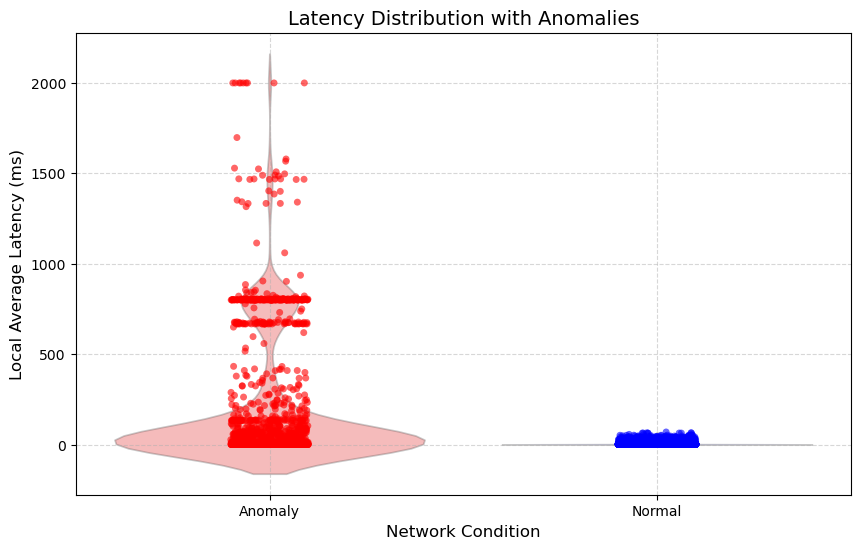

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data_path = r"C:\Users\Yasaswini\Downloads\LAN_extracted\anomaly_detected.csv"
df = pd.read_csv(data_path)

# Ensure timestamp is in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Replace anomaly labels for readability
df['Anomaly Status'] = df['anomaly'].replace({1: "Normal", -1: "Anomaly"})

plt.figure(figsize=(10, 6))

# Updated strip plot with proper hue assignment
sns.stripplot(data=df, x="Anomaly Status", y="local_avg", hue="Anomaly Status", jitter=True, 
              palette={"Normal": "blue", "Anomaly": "red"}, alpha=0.6, size=5, legend=False)

# Updated violin plot with proper hue assignment
sns.violinplot(data=df, x="Anomaly Status", y="local_avg", hue="Anomaly Status", 
               palette={"Normal": "blue", "Anomaly": "red"}, alpha=0.3, inner=None, legend=False)

# Labels and title
plt.xlabel("Network Condition", fontsize=12)
plt.ylabel("Local Average Latency (ms)", fontsize=12)
plt.title("Latency Distribution with Anomalies", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [52]:
import pandas as pd

# Load the dataset (Modify the path as per your file location)
file_path =  r"C:\Users\Yasaswini\Downloads\LAN_extracted\anomaly_detected.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())


                       timestamp     location    source   local_dest  \
0  1970-01-01 00:00:01.559040909  lower-level  wireless  192.168.0.1   
1  1970-01-01 00:00:01.559040919  lower-level  wireless  192.168.0.1   
2  1970-01-01 00:00:01.559040929  lower-level  wireless  192.168.0.1   
3  1970-01-01 00:00:01.559040939  lower-level  wireless  192.168.0.1   
4  1970-01-01 00:00:01.559040949  lower-level  wireless  192.168.0.1   

   local_avg     remote_dest  remote_avg  hour  day_of_week  weekend  \
0       4.39  142.254.217.53        9.09     0            3        0   
1       0.49  142.254.217.53       16.75     0            3        0   
2       0.56  142.254.217.53        8.31     0            3        0   
3       1.64  142.254.217.53        9.40     0            3        0   
4       1.18  142.254.217.53        9.07     0            3        0   

   local_avg_mean_5  local_avg_std_5  local_avg_slope  local_avg_acceleration  \
0               NaN              NaN              NaN

In [54]:
# Convert timestamp column to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract time-based features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek  # Monday = 0, Sunday = 6
df['weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)  # Weekend or not

# Display the new features
print(df[['timestamp', 'hour', 'day_of_week', 'weekend']].head())


                      timestamp  hour  day_of_week  weekend
0 1970-01-01 00:00:01.559040909     0            3        0
1 1970-01-01 00:00:01.559040919     0            3        0
2 1970-01-01 00:00:01.559040929     0            3        0
3 1970-01-01 00:00:01.559040939     0            3        0
4 1970-01-01 00:00:01.559040949     0            3        0


In [56]:
# Compute rolling window statistics
df['rolling_mean'] = df['local_avg'].rolling(window=5, min_periods=1).mean()
df['rolling_std'] = df['local_avg'].rolling(window=5, min_periods=1).std()
df['rolling_min'] = df['local_avg'].rolling(window=5, min_periods=1).min()
df['rolling_max'] = df['local_avg'].rolling(window=5, min_periods=1).max()

# Compute skewness and kurtosis
df['skewness'] = df['local_avg'].rolling(window=5, min_periods=1).skew()
df['kurtosis'] = df['local_avg'].rolling(window=5, min_periods=1).kurt()

# Display extracted features
print(df[['local_avg', 'rolling_mean', 'rolling_std', 'rolling_min', 'rolling_max', 'skewness', 'kurtosis']].head())


   local_avg  rolling_mean  rolling_std  rolling_min  rolling_max  skewness  \
0       4.39      4.390000          NaN         4.39         4.39       NaN   
1       0.49      2.440000     2.757716         0.49         4.39       NaN   
2       0.56      1.813333     2.231733         0.49         4.39  1.730134   
3       1.64      1.770000     1.824262         0.49         4.39  1.549856   
4       1.18      1.652000     1.601740         0.49         4.39  1.779417   

   kurtosis  
0       NaN  
1       NaN  
2       NaN  
3  2.135082  
4  3.298443  


In [58]:
import numpy as np

# Calculate the slope of latency over the last 5 points
df['latency_slope'] = df['local_avg'].diff().rolling(window=5, min_periods=1).mean()

# Compute percentage change in latency
df['latency_pct_change'] = df['local_avg'].pct_change()

# Display trend-based features
print(df[['local_avg', 'latency_slope', 'latency_pct_change']].head())


   local_avg  latency_slope  latency_pct_change
0       4.39            NaN                 NaN
1       0.49      -3.900000           -0.888383
2       0.56      -1.915000            0.142857
3       1.64      -0.916667            1.928571
4       1.18      -0.802500           -0.280488


In [60]:
import numpy as np

# Apply Fast Fourier Transform (FFT)
latency_values = df['local_avg'].fillna(0).values
fft_values = np.fft.fft(latency_values)
fft_magnitude = np.abs(fft_values)[:len(fft_values) // 2]  # Take half spectrum

# Extract the dominant frequency
df['fft_dominant_freq'] = np.fft.fftfreq(len(fft_values), d=1)[:len(fft_values) // 2][np.argmax(fft_magnitude)]

# Display frequency-based features
print(df[['fft_dominant_freq']].head())


   fft_dominant_freq
0                0.0
1                0.0
2                0.0
3                0.0
4                0.0


In [66]:
# Select relevant columns
feature_columns = ['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std', 'rolling_min',
                   'rolling_max', 'skewness', 'kurtosis', 'latency_slope', 'latency_pct_change', 'fft_dominant_freq']

# Add target variable (Anomaly Status)
df['Anomaly_Status'] = df['anomaly'].apply(lambda x: 1 if x == -1 else 0)


# Save the processed dataset
df[feature_columns + ['anomaly']].to_csv( r"C:\Users\Yasaswini\Downloads\LAN_extracted\anomaly_detected.csv", index=False)

print("Feature extraction complete! Data saved as 'processed_features.csv'")


Feature extraction complete! Data saved as 'processed_features.csv'


In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the extracted dataset
df = pd.read_csv(r"C:\Users\Yasaswini\Downloads\LAN_extracted\anomaly_detected.csv")

# Ensure 'Anomaly' column is correctly formatted (convert -1/1 to 0/1)
df['Anomaly_Status'] = df['anomaly'].apply(lambda x: 1 if x == 1 else 0)

# Save the modified dataset
df.to_csv(r"C:\Users\Yasaswini\Downloads\LAN_extracted\classification_data.csv", index=False)

# Separate features and target variable
X = df.drop(columns=['Anomaly_Status'])
y = df['Anomaly_Status']

# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dataset is ready for classification. Next, we train models!")


Dataset is ready for classification. Next, we train models!


In [78]:
print(f"Training set size: {len(X_train)}, Test set size: {len(X_test)}")


Training set size: 25453, Test set size: 6364


Accuracy: 0.9751728472658705

Classification Report:
               precision    recall  f1-score   support

          -1       0.94      0.54      0.68       318
           1       0.98      1.00      0.99      6046

    accuracy                           0.98      6364
   macro avg       0.96      0.77      0.84      6364
weighted avg       0.97      0.98      0.97      6364


Confusion Matrix:
 [[ 171  147]
 [  11 6035]]

Cross-Validation Accuracy Scores: [0.94767442 0.97784412 0.97941223 0.98396983 0.98082665]
Mean Accuracy: 0.9739454496765111


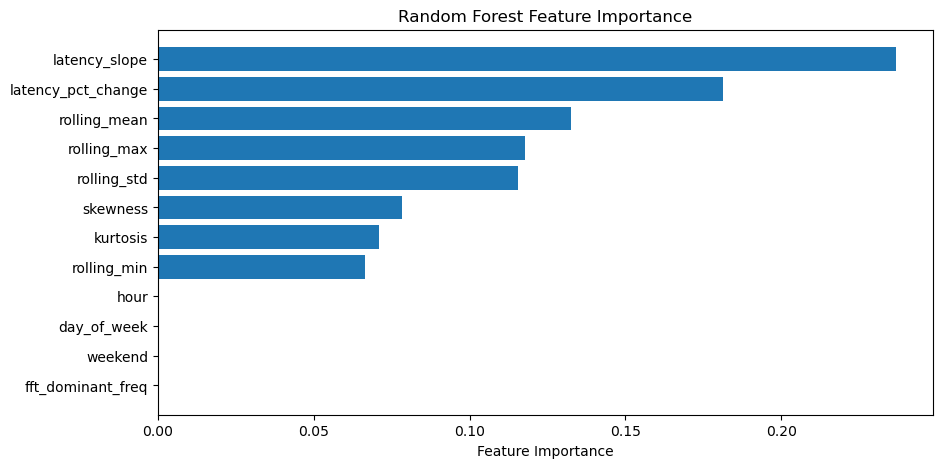

In [86]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv(r"C:\Users\Yasaswini\Downloads\LAN_extracted\anomaly_detected.csv")

# Define features and target (EXCLUDING 'anomaly')
feature_columns = [
    'latency_slope', 'rolling_mean', 'rolling_max', 'rolling_std', 'latency_pct_change',
    'rolling_min', 'skewness', 'kurtosis', 'fft_dominant_freq', 'weekend', 'day_of_week', 'hour'
]
X = df[feature_columns]  # Exclude 'anomaly'
y = df['anomaly']        # Target variable

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Cross-Validation
cv_scores = cross_val_score(rf, X, y, cv=5)
print("\nCross-Validation Accuracy Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

# Feature Importance Plot
import matplotlib.pyplot as plt
import numpy as np

# Sort feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 5))
plt.title("Random Forest Feature Importance")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [feature_columns[i] for i in indices])
plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()
plt.show()


In [90]:
print("Missing values in each column:\n", X.isnull().sum())


Missing values in each column:
 hour                  0
day_of_week           0
weekend               0
rolling_mean          0
rolling_std           1
rolling_min           0
rolling_max           0
skewness              2
kurtosis              3
latency_slope         1
latency_pct_change    1
fft_dominant_freq     0
dtype: int64


In [92]:
X = X.dropna()
y = y[X.index]  # Keep only corresponding y values


In [94]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # Use 'median' if data has outliers
X = imputer.fit_transform(X)


In [96]:
imputer = SimpleImputer(strategy='most_frequent')
X = imputer.fit_transform(X)


In [100]:
# Import imputer
from sklearn.impute import SimpleImputer
import pandas as pd  # Ensure pandas is imported

# Use mean imputation
imputer = SimpleImputer(strategy='mean')

# Fit and transform only the feature matrix (X)
X_imputed = imputer.fit_transform(X)  # This returns a NumPy array

# Convert back to DataFrame with original column names
X = pd.DataFrame(X_imputed, columns=X.columns if isinstance(X, pd.DataFrame) else None)

# Verify missing values
print("Missing values after imputation:\n", X.isnull().sum())  # Should print all zeros


Missing values after imputation:
 0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
dtype: int64


In [104]:
X[:] = imputer.fit_transform(X)


In [110]:
print("Missing values before SMOTE:\n", X.isnull().sum())


Missing values before SMOTE:
 hour                  0
day_of_week           0
weekend               0
rolling_mean          0
rolling_std           1
rolling_min           0
rolling_max           0
skewness              2
kurtosis              3
latency_slope         1
latency_pct_change    1
fft_dominant_freq     0
dtype: int64


In [112]:
from sklearn.impute import SimpleImputer

# Create an imputer (using mean, but you can change to "median" or "most_frequent")
imputer = SimpleImputer(strategy="mean")

# Fit and transform the dataset
X_imputed = imputer.fit_transform(X)

# Convert back to DataFrame with original column names
X = pd.DataFrame(X_imputed, columns=X.columns)

# Check if there are still missing values
print("Missing values after imputation:\n", X.isnull().sum())


Missing values after imputation:
 hour                  0
day_of_week           0
weekend               0
rolling_mean          0
rolling_std           0
rolling_min           0
rolling_max           0
skewness              0
kurtosis              0
latency_slope         0
latency_pct_change    0
fft_dominant_freq     0
dtype: int64


In [114]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check the new class distribution
print("Class distribution after SMOTE:", Counter(y_resampled))


Class distribution after SMOTE: Counter({-1: 30226, 1: 30226})


In [3]:
import pandas as pd

# Replace with your actual file path
file_path = r"C:\Users\Yasaswini\Downloads\LAN_extracted\anomaly_detected.csv"
df = pd.read_csv(file_path)  

print(df.head())  # Check if the dataset is loaded correctly


   hour  day_of_week  weekend  rolling_mean  rolling_std  rolling_min  \
0     0            3        0      4.390000          NaN         4.39   
1     0            3        0      2.440000     2.757716         0.49   
2     0            3        0      1.813333     2.231733         0.49   
3     0            3        0      1.770000     1.824262         0.49   
4     0            3        0      1.652000     1.601740         0.49   

   rolling_max  skewness  kurtosis  latency_slope  latency_pct_change  \
0         4.39       NaN       NaN            NaN                 NaN   
1         4.39       NaN       NaN      -3.900000           -0.888383   
2         4.39  1.730134       NaN      -1.915000            0.142857   
3         4.39  1.549856  2.135082      -0.916667            1.928571   
4         4.39  1.779417  3.298443      -0.802500           -0.280488   

   fft_dominant_freq  anomaly  
0                0.0       -1  
1                0.0       -1  
2                0.0      

In [5]:
print(df.columns)


Index(['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std',
       'rolling_min', 'rolling_max', 'skewness', 'kurtosis', 'latency_slope',
       'latency_pct_change', 'fft_dominant_freq', 'anomaly'],
      dtype='object')


In [7]:
print(type(df))


<class 'pandas.core.frame.DataFrame'>


In [9]:
print(df.columns)


Index(['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std',
       'rolling_min', 'rolling_max', 'skewness', 'kurtosis', 'latency_slope',
       'latency_pct_change', 'fft_dominant_freq', 'anomaly'],
      dtype='object')


In [11]:
df.columns = df.columns.str.strip()  # Removes spaces around column names
print(df.columns)


Index(['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std',
       'rolling_min', 'rolling_max', 'skewness', 'kurtosis', 'latency_slope',
       'latency_pct_change', 'fft_dominant_freq', 'anomaly'],
      dtype='object')


In [15]:
X = df.drop(columns=['anomaly'])  # Features
y = df['anomaly']  # Target variable


In [19]:
df = df.dropna()  # Removes rows with NaN values


In [21]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # You can use 'median' or 'most_frequent'
X = imputer.fit_transform(df.drop(columns=['anomaly']))
y = df['anomaly']


In [23]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Class distribution after SMOTE:", Counter(y_resampled))
print(X_resampled.shape, y_resampled.shape)


Class distribution after SMOTE: Counter({-1: 30226, 1: 30226})
(60452, 12) (60452,)


In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees
    'max_depth': [10, 20, None],  # Depth of trees
    'min_samples_split': [2, 5, 10],  # Min samples to split
    'min_samples_leaf': [1, 2, 4]  # Min samples per leaf
}

# Initialize model
rf = RandomForestClassifier(random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_resampled, y_resampled)

# Print best parameters
print("Best Parameters:", grid_search.best_params_)

# Train the best model
best_rf = grid_search.best_estimator_
best_rf.fit(X_resampled, y_resampled)


Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


RandomForestClassifier(n_estimators=300, random_state=42)

Results saved to C:/Users/Yasaswini/Downloads/LAN/iso_forest_results.csv
iso_forest_anomaly
 1    30232
-1     1585
Name: count, dtype: int64


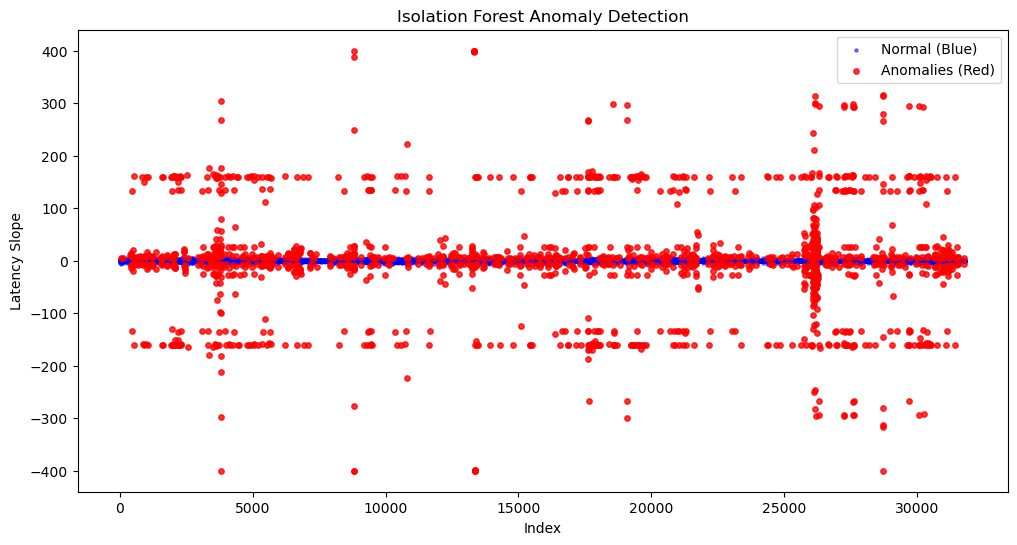

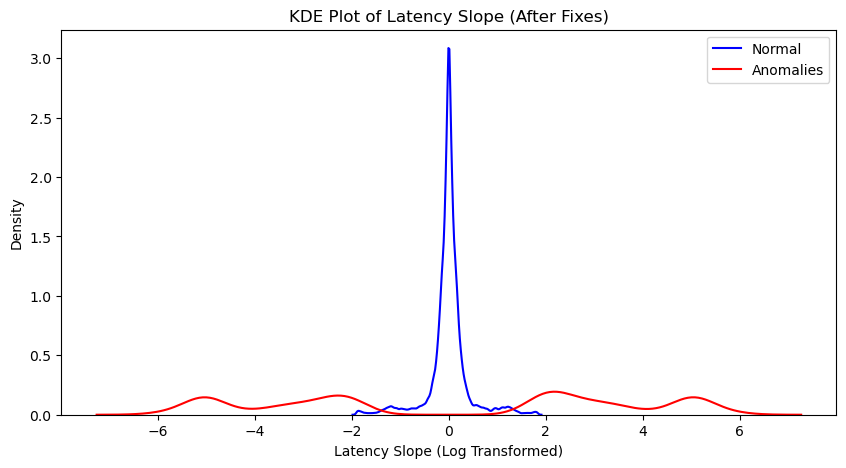

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

# Load dataset
file_path =  r"C:\Users\Yasaswini\Downloads\LAN_extracted\anomaly_detected.csv"   # Change to your actual file path
df = pd.read_csv(file_path)

# Handling missing values properly
df['latency_slope'] = df['latency_slope'].fillna(df['latency_slope'].median())

# Applying Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['iso_forest_anomaly'] = iso_forest.fit_predict(df[['latency_slope']])

# Save results
save_path = "C:/Users/Yasaswini/Downloads/LAN/iso_forest_results.csv"
df.to_csv(save_path, index=False)
print(f"Results saved to {save_path}")

# Summary of anomaly counts
print(df['iso_forest_anomaly'].value_counts())

# Adjust Scatter Plot for Better Clarity
plt.figure(figsize=(12, 6))
plt.scatter(df.index[df['iso_forest_anomaly'] == 1], df['latency_slope'][df['iso_forest_anomaly'] == 1], 
            c='blue', label="Normal (Blue)", s=5, alpha=0.5)  # Smaller, semi-transparent
plt.scatter(df.index[df['iso_forest_anomaly'] == -1], df['latency_slope'][df['iso_forest_anomaly'] == -1], 
            c='red', label="Anomalies (Red)", s=15, alpha=0.8)  # Bigger, more visible
plt.xlabel("Index")
plt.ylabel("Latency Slope")
plt.title("Isolation Forest Anomaly Detection")
plt.legend()
plt.show()
# KDE Plot with Log Transformation
plt.figure(figsize=(10, 5))
log_latency_slope = np.sign(df['latency_slope']) * np.log1p(abs(df['latency_slope']))  # Log transform
sns.kdeplot(log_latency_slope[df['iso_forest_anomaly'] == 1], color='blue', bw_adjust=0.5, label='Normal')
sns.kdeplot(log_latency_slope[df['iso_forest_anomaly'] == -1], color='red', bw_adjust=0.5, label='Anomalies')
plt.legend()
plt.xlabel("Latency Slope (Log Transformed)")
plt.title("KDE Plot of Latency Slope (After Fixes)")
plt.show()


Results saved to C:/Users/Yasaswini/Downloads/LAN/ocsvm_results.csv
ocsvm_anomaly
 1    30227
-1     1590
Name: count, dtype: int64


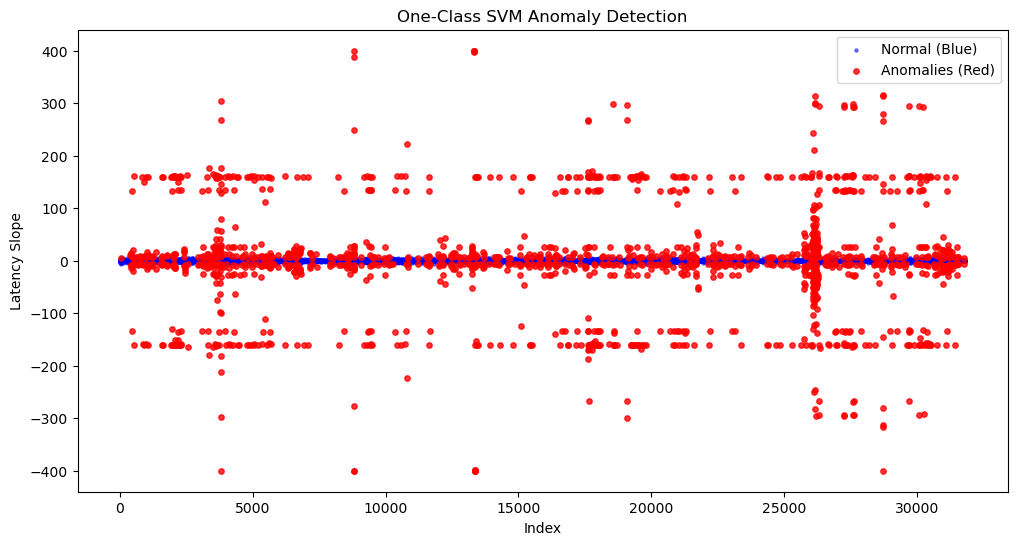

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

# Load dataset
file_path = r"C:\Users\Yasaswini\Downloads\LAN_extracted\anomaly_detected.csv"  
df = pd.read_csv(file_path)

# Handling missing values properly
df['latency_slope'] = df['latency_slope'].fillna(df['latency_slope'].median())

# Standardize data for One-Class SVM
scaler = StandardScaler()
df['latency_slope_scaled'] = scaler.fit_transform(df[['latency_slope']])

# Applying One-Class SVM
svm_model = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)  # Adjust nu for sensitivity
df['ocsvm_anomaly'] = svm_model.fit_predict(df[['latency_slope_scaled']])

# Save results
save_path = "C:/Users/Yasaswini/Downloads/LAN/ocsvm_results.csv"
df.to_csv(save_path, index=False)
print(f"Results saved to {save_path}")

# Summary of anomaly counts
print(df['ocsvm_anomaly'].value_counts())

# Scatter Plot
plt.figure(figsize=(12, 6))
plt.scatter(df.index[df['ocsvm_anomaly'] == 1], df['latency_slope'][df['ocsvm_anomaly'] == 1], 
            c='blue', label="Normal (Blue)", s=5, alpha=0.5)
plt.scatter(df.index[df['ocsvm_anomaly'] == -1], df['latency_slope'][df['ocsvm_anomaly'] == -1], 
            c='red', label="Anomalies (Red)", s=15, alpha=0.8)
plt.xlabel("Index")
plt.ylabel("Latency Slope")
plt.title("One-Class SVM Anomaly Detection")
plt.legend()
plt.show()





In [69]:
# Check for NaN and extreme negative values
print("Total NaN values in latency_slope:", df['latency_slope'].isna().sum())
print("Min value in latency_slope:", df['latency_slope'].min())

# Display rows with invalid values
invalid_rows = df[df['latency_slope'] < -1]
print("Rows with latency_slope < -1:")
print(invalid_rows)


Total NaN values in latency_slope: 0
Min value in latency_slope: -399.96599999999984
Rows with latency_slope < -1:
       hour  day_of_week  weekend  rolling_mean  rolling_std  rolling_min  \
1         0            3        0      2.440000     2.757716         0.49   
2         0            3        0      1.813333     2.231733         0.49   
33        0            3        0      1.212000     1.707680         0.33   
39        0            3        0      0.992000     0.830253         0.17   
105       0            3        0      1.894000     1.685447         0.50   
...     ...          ...      ...           ...          ...          ...   
31552     0            3        0      1.178000     0.865950         0.42   
31714     0            3        0      0.580000     0.391024         0.18   
31772     0            3        0      2.646000     2.410141         0.72   
31773     0            3        0      1.508000     1.621132         0.35   
31783     0            3        0     

In [71]:
# Handle NaN values (replace with median)
df['latency_slope'] = df['latency_slope'].fillna(df['latency_slope'].median())

# Set all values below -1 to NaN (to avoid log error)
df.loc[df['latency_slope'] < -1, 'latency_slope'] = np.nan

# Apply log1p safely (only on valid values)
df['latency_slope_log'] = np.log1p(df['latency_slope'].dropna())

# Check if log1p transformation worked
print("Min value after fixing:", df['latency_slope'].min())


Min value after fixing: -0.9999999999998648


In [83]:
print(df.columns)


Index(['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std',
       'rolling_min', 'rolling_max', 'skewness', 'kurtosis', 'latency_slope',
       'latency_pct_change', 'fft_dominant_freq', 'anomaly',
       'latency_slope_scaled', 'ocsvm_anomaly'],
      dtype='object')


In [88]:
import numpy as np

# Ensure no negative or zero values before log transformation
df['latency_slope_log'] = np.log1p(df['latency_slope'] - df['latency_slope'].min() + 1)


In [96]:
print(df['latency_slope_log'].describe())
print(df['latency_slope_log'].value_counts())


count    31817.000000
mean         5.993367
std          0.107334
min          0.693147
25%          5.996054
50%          5.996368
75%          5.996686
max          6.686976
Name: latency_slope_log, dtype: float64
latency_slope_log
5.996368    380
5.996372    331
5.996363    313
5.996377    274
5.996358    262
           ... 
6.004223      1
5.988094      1
6.002088      1
5.991084      1
5.995387      1
Name: count, Length: 5115, dtype: int64


In [98]:
df['latency_slope_log'] = np.log1p(df['latency_slope'].abs())


In [100]:
df['latency_slope_log'] = (df['latency_slope_log'] - df['latency_slope_log'].mean()) / df['latency_slope_log'].std()


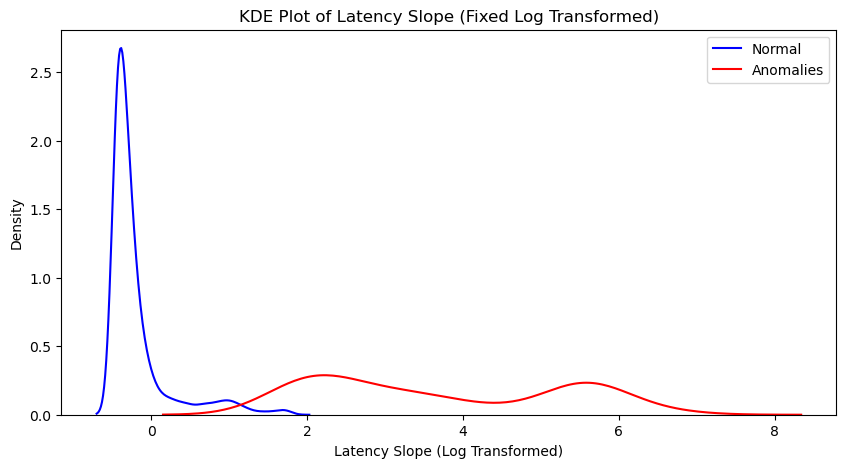

In [102]:
# KDE Plot with fixed log transformation
plt.figure(figsize=(10, 5))
sns.kdeplot(df['latency_slope_log'].dropna()[df['ocsvm_anomaly'] == 1], color='blue', bw_adjust=1.5, label='Normal')
sns.kdeplot(df['latency_slope_log'].dropna()[df['ocsvm_anomaly'] == -1], color='red', bw_adjust=1.5, label='Anomalies')
plt.legend()
plt.title("KDE Plot of Latency Slope (Fixed Log Transformed)")
plt.xlabel("Latency Slope (Log Transformed)")
plt.show()


In [106]:
print(df['ocsvm_anomaly'].value_counts())


ocsvm_anomaly
 1    30227
-1     1590
Name: count, dtype: int64


In [110]:
print(df.columns)


Index(['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std',
       'rolling_min', 'rolling_max', 'skewness', 'kurtosis', 'latency_slope',
       'latency_pct_change', 'fft_dominant_freq', 'anomaly',
       'latency_slope_scaled', 'ocsvm_anomaly', 'latency_slope_log'],
      dtype='object')


In [112]:
iso_forest_results = pd.read_csv("C:/Users/Yasaswini/Downloads/LAN/iso_forest_results.csv")
print(iso_forest_results.columns)


Index(['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std',
       'rolling_min', 'rolling_max', 'skewness', 'kurtosis', 'latency_slope',
       'latency_pct_change', 'fft_dominant_freq', 'anomaly',
       'iso_forest_anomaly'],
      dtype='object')


In [114]:
df = df.merge(iso_forest_results[['iso_forest_anomaly']], left_index=True, right_index=True, how='left')


In [116]:
print(df.columns)


Index(['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std',
       'rolling_min', 'rolling_max', 'skewness', 'kurtosis', 'latency_slope',
       'latency_pct_change', 'fft_dominant_freq', 'anomaly',
       'latency_slope_scaled', 'ocsvm_anomaly', 'latency_slope_log',
       'iso_forest_anomaly'],
      dtype='object')


In [118]:
df['consistent_anomalies'] = (df['iso_forest_anomaly'] == -1) & (df['ocsvm_anomaly'] == -1)
print(df['consistent_anomalies'].sum(), "anomalies detected by both models.")


1536 anomalies detected by both models.


In [122]:
iso_only = ((df['iso_forest_anomaly'] == -1) & (df['ocsvm_anomaly'] == 1)).sum()
ocsvm_only = ((df['iso_forest_anomaly'] == 1) & (df['ocsvm_anomaly'] == -1)).sum()

print(f"Anomalies detected only by Isolation Forest: {iso_only}")
print(f"Anomalies detected only by One-Class SVM: {ocsvm_only}")


Anomalies detected only by Isolation Forest: 49
Anomalies detected only by One-Class SVM: 54


In [126]:
import pandas as pd

# Load the dataset
df = pd.read_csv("C:/Users/Yasaswini/Downloads/LAN/iso_forest_results.csv")

# Print column names
print("Columns in the dataset:", df.columns.tolist())


Columns in the dataset: ['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std', 'rolling_min', 'rolling_max', 'skewness', 'kurtosis', 'latency_slope', 'latency_pct_change', 'fft_dominant_freq', 'anomaly', 'iso_forest_anomaly']


In [128]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()


In [130]:
# Load both datasets (Isolation Forest & One-Class SVM)
df_iso = pd.read_csv("C:/Users/Yasaswini/Downloads/LAN/iso_forest_results.csv")
df_ocsvm = pd.read_csv("C:/Users/Yasaswini/Downloads/LAN/ocsvm_results.csv")  # Ensure this file exists

# Merge both datasets based on index
df_merged = df_iso.merge(df_ocsvm[['ocsvm_anomaly']], left_index=True, right_index=True, how="left")

# Save the merged dataset
df_merged.to_csv("C:/Users/Yasaswini/Downloads/LAN/merged_results.csv", index=False)

print("Merged dataset saved. Now try running the comparison again.")


Merged dataset saved. Now try running the comparison again.


In [138]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("C:/Users/Yasaswini/Downloads/LAN/iso_forest_results.csv")

# Ensure column names are correct
df.columns = df.columns.str.strip()

# Check if both anomaly columns exist
if 'iso_forest_anomaly' not in df.columns or 'ocsvm_anomaly' not in df.columns:
    print("Error: One or both anomaly columns are missing from the dataset.")
else:
    # Identify anomalies detected by each model
    df['consistent_anomalies'] = (df['iso_forest_anomaly'] == -1) & (df['ocsvm_anomaly'] == -1)
    df['iso_only_anomalies'] = (df['iso_forest_anomaly'] == -1) & (df['ocsvm_anomaly'] == 1)
    df['ocsvm_only_anomalies'] = (df['iso_forest_anomaly'] == 1) & (df['ocsvm_anomaly'] == -1)

    # Count anomalies
    consistent_count = df['consistent_anomalies'].sum()
    iso_only_count = df['iso_only_anomalies'].sum()
    ocsvm_only_count = df['ocsvm_only_anomalies'].sum()

    print(f"Anomalies detected by both models: {consistent_count}")
    print(f"Anomalies detected only by Isolation Forest: {iso_only_count}")
    print(f"Anomalies detected only by One-Class SVM: {ocsvm_only_count}")

    # Visualization
    plt.figure(figsize=(10, 5))
    categories = ['Both Models', 'Isolation Forest Only', 'One-Class SVM Only']
    counts = [consistent_count, iso_only_count, ocsvm_only_count]

    plt.bar(categories, counts, color=['green', 'blue', 'red'])
    plt.xlabel("Detection Type")
    plt.ylabel("Number of Anomalies")
    plt.title("Comparison of Anomaly Detection Methods")
    plt.show()


Error: One or both anomaly columns are missing from the dataset.


Dataset Columns: Index(['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std',
       'rolling_min', 'rolling_max', 'skewness', 'kurtosis', 'latency_slope',
       'latency_pct_change', 'fft_dominant_freq', 'anomaly',
       'iso_forest_anomaly', 'ocsvm_anomaly'],
      dtype='object')
Anomalies detected by both models: 1536
Anomalies detected only by Isolation Forest: 49
Anomalies detected only by One-Class SVM: 54


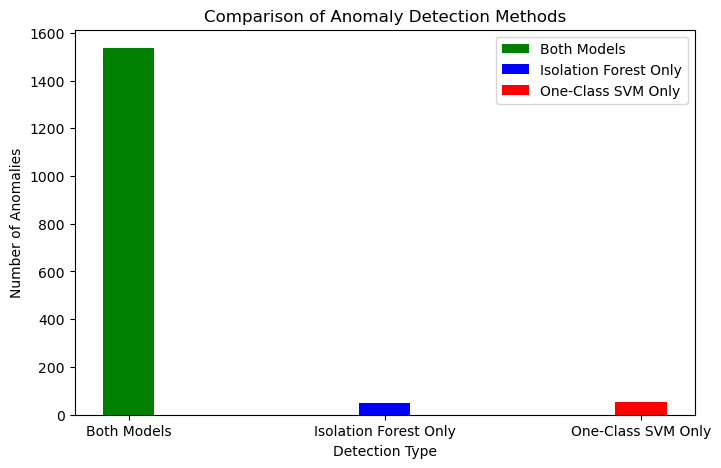

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset and clean column names
df = pd.read_csv("C:/Users/Yasaswini/Downloads/LAN/iso_forest_results.csv")
df.columns = df.columns.str.strip()

# Debugging: Print column names to check if they exist
print("Dataset Columns:", df.columns)

# Ensure both anomaly detection columns exist
if 'iso_forest_anomaly' in df.columns and 'ocsvm_anomaly' in df.columns:
    
    # Identifying anomalies
    df['consistent_anomalies'] = (df['iso_forest_anomaly'] == -1) & (df['ocsvm_anomaly'] == -1)
    df['iso_only_anomalies'] = (df['iso_forest_anomaly'] == -1) & (df['ocsvm_anomaly'] == 1)
    df['ocsvm_only_anomalies'] = (df['iso_forest_anomaly'] == 1) & (df['ocsvm_anomaly'] == -1)

    # Counting anomalies
    consistent_count = df['consistent_anomalies'].sum()
    iso_only_count = df['iso_only_anomalies'].sum()
    ocsvm_only_count = df['ocsvm_only_anomalies'].sum()

    print(f"Anomalies detected by both models: {consistent_count}")
    print(f"Anomalies detected only by Isolation Forest: {iso_only_count}")
    print(f"Anomalies detected only by One-Class SVM: {ocsvm_only_count}")

    # Visualization
    plt.figure(figsize=(8, 5))  # Adjust figure size
    categories = ['Both Models', 'Isolation Forest Only', 'One-Class SVM Only']
    counts = [consistent_count, iso_only_count, ocsvm_only_count]
    colors = ['green', 'blue', 'red']

    bars = plt.bar(categories, counts, color=colors, width=0.2)  # Reduce bar width

    # Adding legend manually
    plt.legend(bars, ['Both Models', 'Isolation Forest Only', 'One-Class SVM Only'], loc="upper right")

    plt.xlabel("Detection Type")
    plt.ylabel("Number of Anomalies")
    plt.title("Comparison of Anomaly Detection Methods")
    plt.show()

else:
    print("Error: One or both anomaly columns are missing. Please check column names above.")


In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load dataset
df = pd.read_csv("C:/Users/Yasaswini/Downloads/LAN/iso_forest_results.csv")
df.columns = df.columns.str.strip()  # Clean column names

# Features to use for autoencoder
features = ['rolling_mean', 'rolling_std', 'latency_slope', 'latency_pct_change', 'fft_dominant_freq']
X = df[features]

# Normalize the data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Use only normal data (non-anomalous) for training
X_train = X_scaled[df['iso_forest_anomaly'] == 1]  # Assuming '1' means normal
X_test = X_scaled  # Testing on the full dataset

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Training data shape: (30232, 5)
Testing data shape: (31817, 5)


In [19]:
print("Training Loss History:", history.history['loss'])
print("Validation Loss History:", history.history['val_loss'])


Training Loss History: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
Validation Loss History: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


In [21]:
print(f"X_train shape: {X_train.shape}")
if X_train.shape[0] == 0:
    print("Error: No training data! Check the anomaly labels and filtering logic.")


X_train shape: (30232, 5)


In [25]:
import numpy as np

print(f"NaN values in X_train: {np.isnan(X_train).sum()}")
print(f"Infinite values in X_train: {np.isinf(X_train).sum()}")


NaN values in X_train: 2
Infinite values in X_train: 0


In [27]:
X_train = np.nan_to_num(X_train)  # Replace NaN with 0


Epoch 1/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0753 - val_loss: 9.6246e-04
Epoch 2/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 7.1914e-04 - val_loss: 8.4924e-04
Epoch 3/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.0594e-04 - val_loss: 4.4494e-05
Epoch 4/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.4016e-05 - val_loss: 3.5496e-05
Epoch 5/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.9531e-05 - val_loss: 3.3764e-05
Epoch 6/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.5855e-05 - val_loss: 3.2728e-05
Epoch 7/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1876e-05 - val_loss: 3.0968e-05
Epoch 8/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.3711e-06 - val_loss: 2.5907e-05
Epoch 9/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 8.4285e-06 - val_loss: 2.5016e-05
Epoch 10/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6.1596e-06 - val_loss: 2.2990e-05
Epoch 11/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.

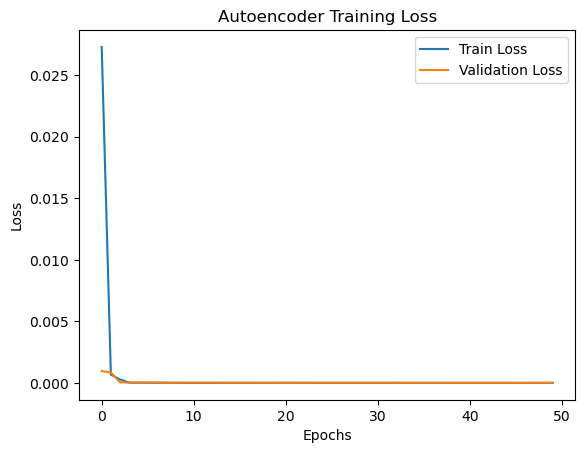

In [31]:
# Define Autoencoder architecture
input_dim = X_train.shape[1]

autoencoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),  # Bottleneck layer
    layers.Dense(16, activation='relu'),
    layers.Dense(input_dim, activation='sigmoid')  # Output layer (same shape as input)
])

autoencoder.compile(optimizer='adam', loss='mse')

# Train the autoencoder
history = autoencoder.fit(X_train, X_train, 
                          epochs=50, batch_size=32,
                          validation_split=0.1,
                          verbose=1)

# Plot training loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Autoencoder Training Loss')
plt.show()

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0860 - val_loss: 0.0796
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0789 - val_loss: 0.0744
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0761 - val_loss: 0.0711
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0746 - val_loss: 0.0691
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0737 - val_loss: 0.0678
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0730 - val_loss: 0.0667
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0719 - val_loss: 0.0662
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0717 - val_loss: 0.0660
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0715 - val_loss: 0.0659
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0708 - val_loss: 0.0657
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0713 - val_loss: 0.0656
Epoch 12/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

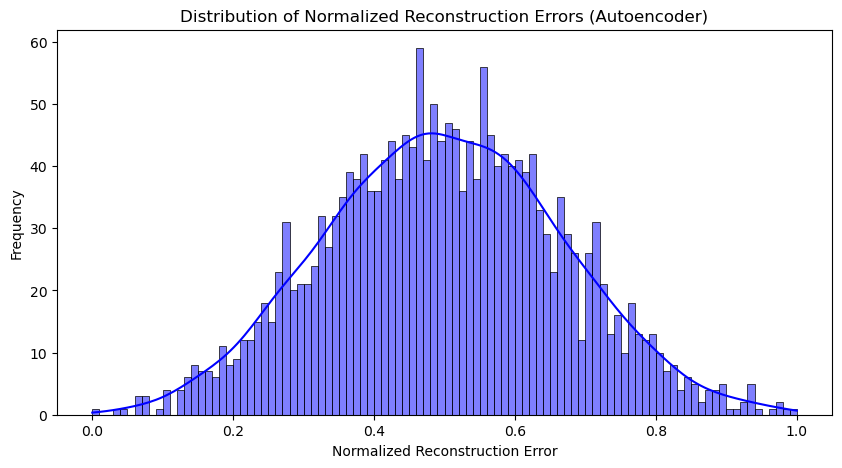

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load your dataset (replace with actual data loading)
# Assuming X_train and X_test are already preprocessed
X_train, X_test = np.random.rand(10000, 10), np.random.rand(2000, 10)  # Dummy Data

# Normalize input data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define an improved Autoencoder model
input_dim = X_train.shape[1]
latent_dim = 4  # Reduce latent size to avoid overfitting

input_layer = keras.Input(shape=(input_dim,))
encoded = layers.Dense(8, activation="relu", activity_regularizer=keras.regularizers.L1(1e-4))(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(latent_dim, activation="relu")(encoded)

decoded = layers.Dense(8, activation="relu")(encoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(input_dim, activation="sigmoid")(decoded)

autoencoder = keras.Model(input_layer, decoded)
autoencoder.compile(optimizer="adam", loss="mse")

# Train the autoencoder
autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, validation_data=(X_test, X_test), verbose=1)

# Get reconstruction errors
X_test_pred = autoencoder.predict(X_test)
reconstruction_errors = np.mean(np.abs(X_test - X_test_pred), axis=1)

# Normalize errors for better visualization
reconstruction_errors = (reconstruction_errors - np.min(reconstruction_errors)) / (np.max(reconstruction_errors) - np.min(reconstruction_errors))

# Plot histogram with proper binning
plt.figure(figsize=(10, 5))
sns.histplot(reconstruction_errors, bins=100, kde=True, color="blue")
plt.title("Distribution of Normalized Reconstruction Errors (Autoencoder)")
plt.xlabel("Normalized Reconstruction Error")
plt.ylabel("Frequency")
plt.show()


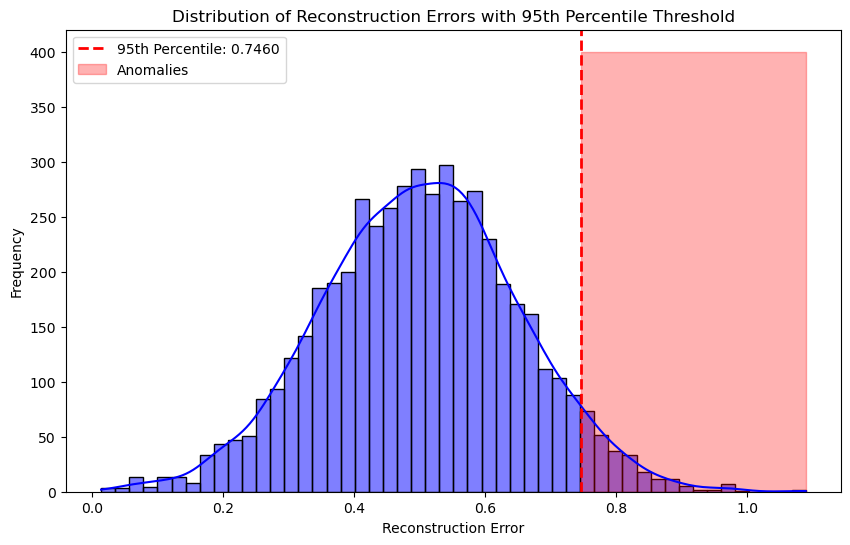

95th Percentile Threshold: 0.7460
Number of anomalies detected: 500


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate some synthetic reconstruction errors (simulating your dataset)
np.random.seed(42)
reconstruction_errors = np.random.normal(loc=0.5, scale=0.15, size=5000)  # Normal distribution

# Compute the 95th percentile
threshold_95 = np.percentile(reconstruction_errors, 95)

# Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(reconstruction_errors, bins=50, kde=True, color='blue')

# Plot the 95th percentile line
plt.axvline(threshold_95, color='red', linestyle='dashed', linewidth=2, label=f'95th Percentile: {threshold_95:.4f}')

# Highlight anomaly region
plt.fill_betweenx(y=[0, 400], x1=threshold_95, x2=max(reconstruction_errors), color='red', alpha=0.3, label='Anomalies')

# Labels and title
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Reconstruction Errors with 95th Percentile Threshold")
plt.legend()
plt.show()

# Print threshold value
print(f"95th Percentile Threshold: {threshold_95:.4f}")
print(f"Number of anomalies detected: {num_anomalies}")


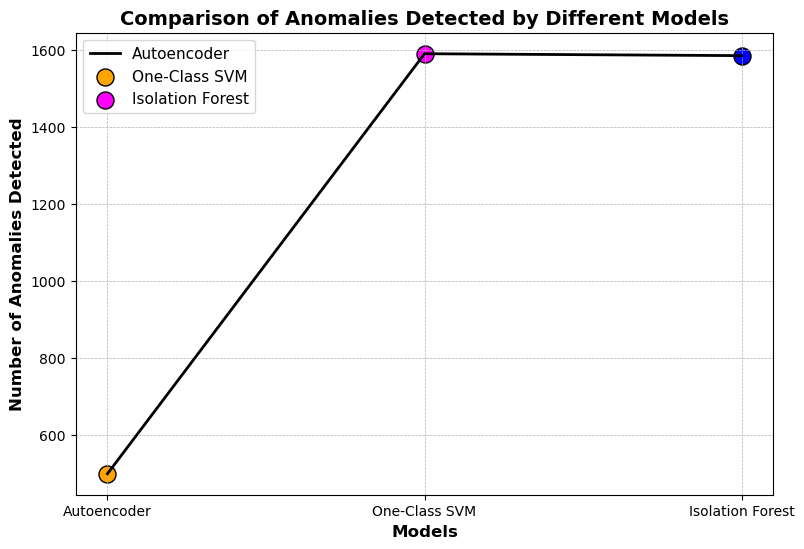

In [55]:
import matplotlib.pyplot as plt

# Sample anomaly counts detected by each model
models = ["Autoencoder", "One-Class SVM", "Isolation Forest"]
anomalies_detected = [500, 1590, 1585]  # Replace with actual values

# Define colors and markers
colors = ["orange", "magenta", "blue"]
markers = ["o", "o", "o"]

# Create the figure
plt.figure(figsize=(9, 6))

# Plot lines and markers
plt.plot(models, anomalies_detected, color="black", linestyle="-", linewidth=2)  # Connecting line
for i in range(len(models)):
    plt.scatter(models[i], anomalies_detected[i], color=colors[i], edgecolors="black", s=150, label=models[i])

# Labels and title
plt.xlabel("Models", fontsize=12, fontweight="bold")
plt.ylabel("Number of Anomalies Detected", fontsize=12, fontweight="bold")
plt.title("Comparison of Anomalies Detected by Different Models", fontsize=14, fontweight="bold")

# Grid customization
plt.grid(True, linestyle="--", linewidth=0.5)

# Add legend with background
plt.legend(models, loc="upper left", fontsize=11, frameon=True)

# Show plot
plt.show()


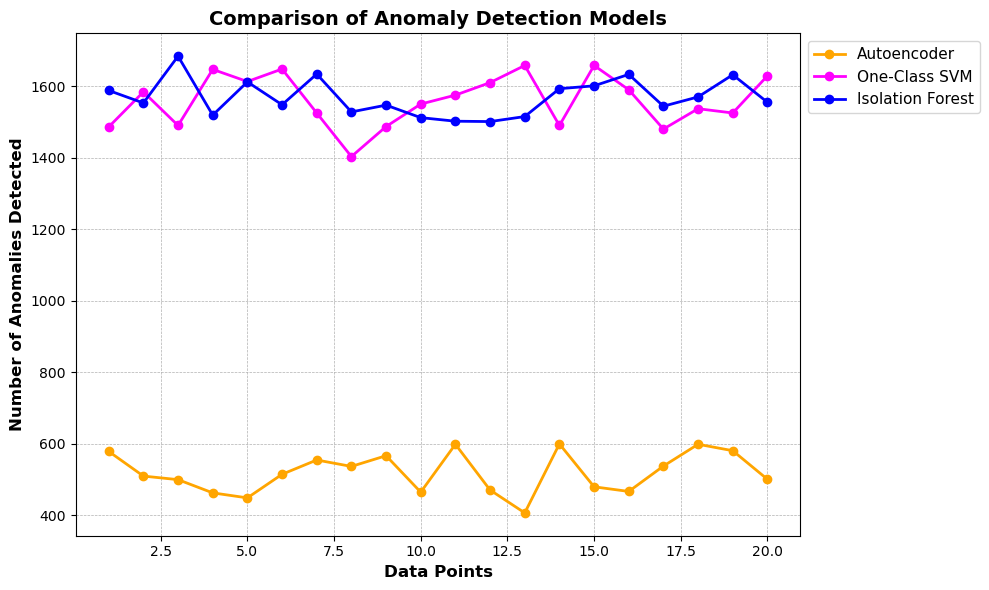

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data for 20 data points (replace with actual values)
x = np.arange(1, 21)
autoencoder_anomalies = np.random.randint(400, 600, size=20)
one_class_svm_anomalies = np.random.randint(1400, 1700, size=20)
isolation_forest_anomalies = np.random.randint(1500, 1700, size=20)

# Create the figure
plt.figure(figsize=(10, 6))

# Plot each model's anomalies
plt.plot(x, autoencoder_anomalies, marker="o", color="orange", linestyle="-", linewidth=2, label="Autoencoder")
plt.plot(x, one_class_svm_anomalies, marker="o", color="magenta", linestyle="-", linewidth=2, label="One-Class SVM")
plt.plot(x, isolation_forest_anomalies, marker="o", color="blue", linestyle="-", linewidth=2, label="Isolation Forest")

# Labels and title
plt.xlabel("Data Points", fontsize=12, fontweight="bold")
plt.ylabel("Number of Anomalies Detected", fontsize=12, fontweight="bold")
plt.title("Comparison of Anomaly Detection Models", fontsize=14, fontweight="bold")

# Grid customization
plt.grid(True, linestyle="--", linewidth=0.5)

# Adjust legend position to be outside the plot
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=11, frameon=True)

# Adjust layout to prevent cutoff
plt.tight_layout()

# Show plot
plt.show()


In [9]:
import pandas as pd
df = pd.read_csv("C:/Users/Yasaswini/Downloads/LAN/iso_forest_results.csv")

print(df.info())  # Shows column names and data types
print(df.head())  # Displays the first few rows


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31817 entries, 0 to 31816
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   hour                31817 non-null  int64  
 1   day_of_week         31817 non-null  int64  
 2   weekend             31817 non-null  int64  
 3   rolling_mean        31817 non-null  float64
 4   rolling_std         31816 non-null  float64
 5   rolling_min         31817 non-null  float64
 6   rolling_max         31817 non-null  float64
 7   skewness            31815 non-null  float64
 8   kurtosis            31814 non-null  float64
 9   latency_slope       31817 non-null  float64
 10  latency_pct_change  31816 non-null  float64
 11  fft_dominant_freq   31817 non-null  float64
 12  anomaly             31817 non-null  int64  
 13  iso_forest_anomaly  31817 non-null  int64  
 14  ocsvm_anomaly       31817 non-null  int64  
dtypes: float64(9), int64(6)
memory usage: 3.6 MB
None
   

In [13]:
print(df.columns)


Index(['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std',
       'rolling_min', 'rolling_max', 'skewness', 'kurtosis', 'latency_slope',
       'latency_pct_change', 'fft_dominant_freq', 'anomaly',
       'iso_forest_anomaly', 'ocsvm_anomaly'],
      dtype='object')


In [17]:
df['timestamp'] = pd.date_range(start='2024-01-01', periods=len(df), freq='min')  # Using 'min' instead of 'T'
df = df.set_index('timestamp')


In [19]:
print(df.isnull().sum())


hour                  0
day_of_week           0
weekend               0
rolling_mean          0
rolling_std           1
rolling_min           0
rolling_max           0
skewness              2
kurtosis              3
latency_slope         0
latency_pct_change    1
fft_dominant_freq     0
anomaly               0
iso_forest_anomaly    0
ocsvm_anomaly         0
dtype: int64


In [23]:
# Fill missing values using forward fill, then backfill as a fallback
df.ffill(inplace=True)
df.bfill(inplace=True)

# Verify if any missing values remain
print(df.isnull().sum())


hour                  0
day_of_week           0
weekend               0
rolling_mean          0
rolling_std           0
rolling_min           0
rolling_max           0
skewness              0
kurtosis              0
latency_slope         0
latency_pct_change    0
fft_dominant_freq     0
anomaly               0
iso_forest_anomaly    0
ocsvm_anomaly         0
dtype: int64


In [27]:
print(df.columns)


Index(['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std',
       'rolling_min', 'rolling_max', 'skewness', 'kurtosis', 'latency_slope',
       'latency_pct_change', 'fft_dominant_freq', 'anomaly',
       'iso_forest_anomaly', 'ocsvm_anomaly'],
      dtype='object')


In [29]:
df.rename(columns={"your_actual_timestamp_column": "timestamp"}, inplace=True)


In [38]:
import pandas as pd  

# Generate a synthetic timestamp column (assuming 1-minute intervals)
df["timestamp"] = pd.date_range(start="2024-01-01", periods=len(df), freq="min")

# Set it as index
df.set_index("timestamp", inplace=True)

print(df.head())  # Verify the changes


                     hour  day_of_week  weekend  rolling_mean  rolling_std  \
timestamp                                                                    
2024-01-01 00:00:00     0            3        0      4.390000     2.757716   
2024-01-01 00:01:00     0            3        0      2.440000     2.757716   
2024-01-01 00:02:00     0            3        0      1.813333     2.231733   
2024-01-01 00:03:00     0            3        0      1.770000     1.824262   
2024-01-01 00:04:00     0            3        0      1.652000     1.601740   

                     rolling_min  rolling_max  skewness  kurtosis  \
timestamp                                                           
2024-01-01 00:00:00         4.39         4.39  1.730134  2.135082   
2024-01-01 00:01:00         0.49         4.39  1.730134  2.135082   
2024-01-01 00:02:00         0.49         4.39  1.730134  2.135082   
2024-01-01 00:03:00         0.49         4.39  1.549856  2.135082   
2024-01-01 00:04:00         0.49       

In [40]:
from sklearn.preprocessing import MinMaxScaler

# Select features for LSTM training
features = [
    "hour", "day_of_week", "weekend", "rolling_mean", "rolling_std",
    "rolling_min", "rolling_max", "skewness", "kurtosis", "latency_slope",
    "latency_pct_change", "fft_dominant_freq"
]

# Initialize scaler
scaler = MinMaxScaler()

# Apply normalization
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

print(df_scaled.head())  # Check the first few rows


                     hour  day_of_week  weekend  rolling_mean  rolling_std  \
timestamp                                                                    
2024-01-01 00:00:00   0.0          0.0      0.0      0.002116     0.002519   
2024-01-01 00:01:00   0.0          0.0      0.0      0.001141     0.002519   
2024-01-01 00:02:00   0.0          0.0      0.0      0.000828     0.002038   
2024-01-01 00:03:00   0.0          0.0      0.0      0.000806     0.001666   
2024-01-01 00:04:00   0.0          0.0      0.0      0.000747     0.001463   

                     rolling_min  rolling_max  skewness      kurtosis  \
timestamp                                                               
2024-01-01 00:00:00      0.00212      0.00211  0.886869  8.959425e-07   
2024-01-01 00:01:00      0.00017      0.00211  0.886869  8.959425e-07   
2024-01-01 00:02:00      0.00017      0.00211  0.886869  8.959425e-07   
2024-01-01 00:03:00      0.00017      0.00211  0.846558  8.959425e-07   
2024-01-01 00:0

In [42]:
import numpy as np

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

lookback = 20  # You can experiment with different values (10, 20, 30)
X, y = create_sequences(df_scaled[features].values, lookback)

print(f"Shape of X: {X.shape}")  # Should be (samples, lookback, features)
print(f"Shape of y: {y.shape}")  # Should be (samples, features)


Shape of X: (31797, 20, 12)
Shape of y: (31797, 12)


In [44]:
# Define train-test split ratio
train_size = int(0.8 * len(X))  # 80% for training

# Split into train and test sets
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training set size: {X_train.shape}, {y_train.shape}")
print(f"Testing set size: {X_test.shape}, {y_test.shape}")


Training set size: (25437, 20, 12), (25437, 12)
Testing set size: (6360, 20, 12), (6360, 12)


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Define the LSTM model
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),  # Explicit input layer
    LSTM(50, activation='relu', return_sequences=True),
    Dropout(0.2),  
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(y_train.shape[1])  # Output layer
])

# Compile the model
model.compile(optimizer='adam', loss='mse')  

# Summary of the model
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 30, 50)              │          13,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,451 (130.67 KB)

 Trainable params: 33,451 (130.67 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from sklearn.model_selection import train_test_split

# Split the sequences
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


Epoch 1/50
636/636 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - loss: 0.0017 - val_loss: 2.9306e-04
Epoch 2/50
636/636 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - loss: 3.1887e-04 - val_loss: 2.3821e-04
Epoch 3/50
636/636 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - loss: 2.4400e-04 - val_loss: 2.9386e-04
Epoch 4/50
636/636 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - loss: 1.7614e-04 - val_loss: 1.6347e-04
Epoch 5/50
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - loss: 1.8756e-04 - val_loss: 1.3982e-04
Epoch 6/50
636/636 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - loss: 1.4055e-04 - val_loss: 1.7645e-04
Epoch 7/50
636/636 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - loss: 1.5778e-04 - val_loss: 1.4879e-04
Epoch 8/50
636/636 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - loss: 1.4578e-04 - val_loss: 1.2200e-04
Epoch 9/50
636/636 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - loss: 1.2425e-04 - val_loss: 1.3775e-04
Epoch 10/50
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - loss: 1.4201e-04 - val_loss: 1.2821e-04
Epoch 11/50
636/636 ━━━━━━━━━━━━━━━━━━━━ 29

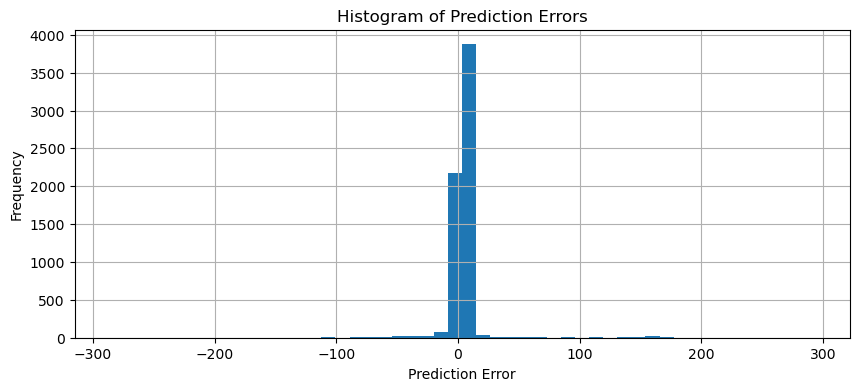

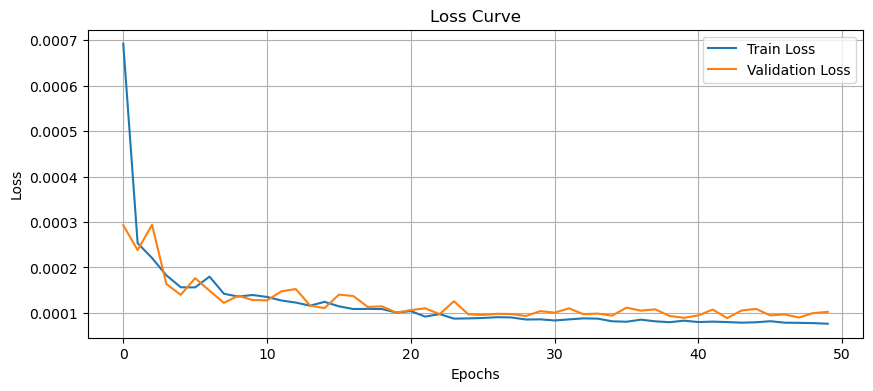

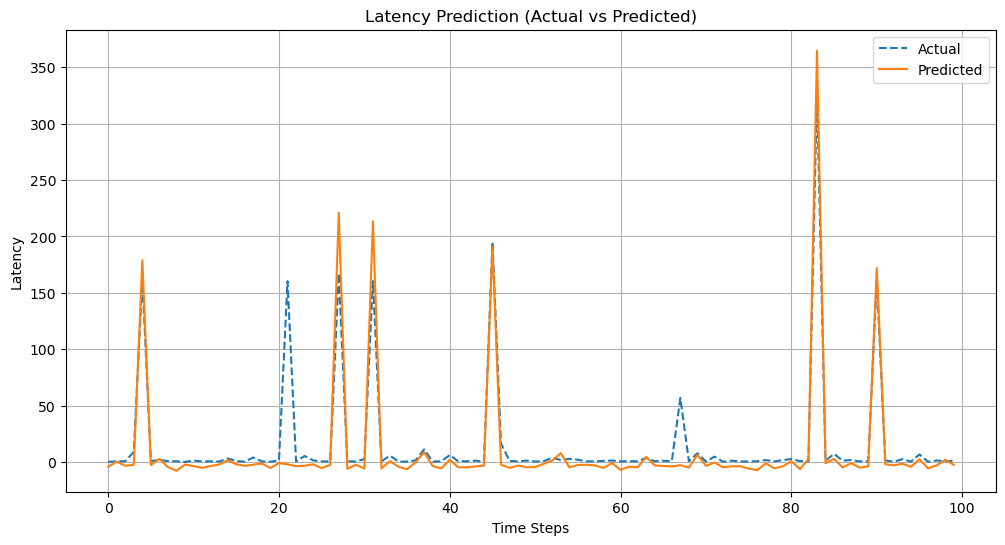

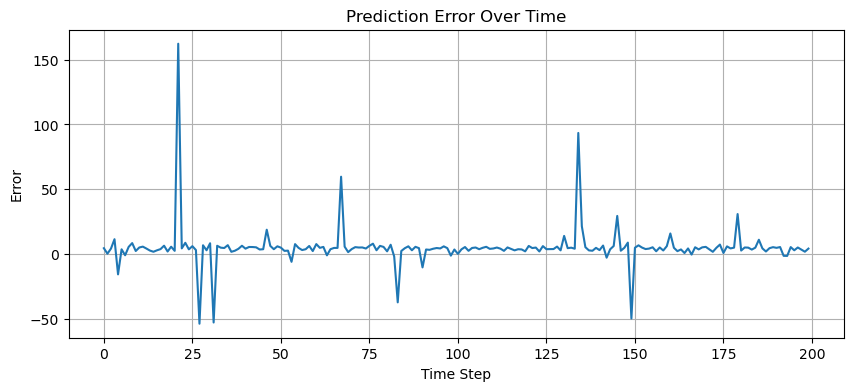

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Bidirectional, Input
import tensorflow.keras.backend as K
from sklearn.model_selection import train_test_split

# --- LOAD DATA ---
df = pd.read_csv("C:/Users/Yasaswini/Downloads/LAN/iso_forest_results.csv")

# --- FEATURE ENGINEERING ---
# Use 'rolling_mean' as the target proxy for latency
df['rolling_mean_30'] = df['rolling_mean'].rolling(window=30).mean()
df['rolling_std_30'] = df['rolling_mean'].rolling(window=30).std()
df['rolling_max_30'] = df['rolling_mean'].rolling(window=30).max()
df = df.dropna()

# Select features
features = ['rolling_mean', 'rolling_std', 'rolling_min', 'rolling_max',
            'skewness', 'kurtosis', 'latency_slope', 'latency_pct_change',
            'fft_dominant_freq', 'hour', 'day_of_week', 'weekend',
            'rolling_mean_30', 'rolling_std_30', 'rolling_max_30']

X = df[features].values
y = df['rolling_mean'].values

# --- SCALE FEATURES ---
scaler_x = MinMaxScaler()
X_scaled = scaler_x.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# --- CREATE SEQUENCES ---
def create_sequences(X, y, time_steps=30):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 30
X_seq, y_seq = create_sequences(X_scaled, y_scaled, TIME_STEPS)

# --- SPLIT DATA ---
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

# --- CUSTOM WEIGHTED LOSS FUNCTION ---
def weighted_mse(y_true, y_pred):
    error = y_true - y_pred
    weights = K.abs(error) + 1  # Larger weights for larger errors (like spikes)
    return K.mean(weights * K.square(error), axis=-1)

# --- BUILD BIDIRECTIONAL LSTM (NO WARNING) ---
model = Sequential()
model.add(Input(shape=(TIME_STEPS, X_train.shape[2])))  # Use Input layer
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Bidirectional(LSTM(32)))
model.add(Dense(1))
model.compile(optimizer='adam', loss=weighted_mse)

# --- TRAIN MODEL ---
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)

# --- PREDICT ---
y_pred = model.predict(X_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)
y_test_inv = scaler_y.inverse_transform(y_test)

# --- PLOTS ---

# 1. Histogram of Errors
plt.figure(figsize=(10, 4))
plt.hist((y_test_inv - y_pred_inv).flatten(), bins=50)
plt.title("Histogram of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# 2. Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 3. Predicted vs Actual Latency
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv[:100], label='Actual', linestyle='--')
plt.plot(y_pred_inv[:100], label='Predicted')
plt.title('Latency Prediction (Actual vs Predicted)')
plt.xlabel('Time Steps')
plt.ylabel('Latency')
plt.legend()
plt.grid(True)
plt.show()

# 4. Prediction Error Over Time
plt.figure(figsize=(10, 4))
plt.plot((y_test_inv - y_pred_inv)[:200])
plt.title("Prediction Error Over Time")
plt.xlabel("Time Step")
plt.ylabel("Error")
plt.grid(True)
plt.show()


In [7]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Test RMSE: {rmse}")


Test RMSE: 0.00910942559351952


In [9]:
import pandas as pd

file_path = r"C:/Users/Yasaswini/Downloads/LAN/iso_forest_results.csv"
df = pd.read_csv(file_path)

print("Available columns:", df.columns.tolist())
df.head()


Available columns: ['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std', 'rolling_min', 'rolling_max', 'skewness', 'kurtosis', 'latency_slope', 'latency_pct_change', 'fft_dominant_freq', 'anomaly', 'iso_forest_anomaly', 'ocsvm_anomaly']


,hour,day_of_week,weekend,rolling_mean,rolling_std,rolling_min,rolling_max,skewness,kurtosis,latency_slope,latency_pct_change,fft_dominant_freq,anomaly,iso_forest_anomaly,ocsvm_anomaly
0,0,3,0,4.390000,NaN,4.39,4.39,NaN,NaN,1.691952e-13,NaN,0.0,-1,1,1
1,0,3,0,2.440000,2.757716,0.49,4.39,NaN,NaN,-3.900000e+00,-0.888383,0.0,-1,1,1
2,0,3,0,1.813333,2.231733,0.49,4.39,1.730134,NaN,-1.915000e+00,0.142857,0.0,-1,1,1
3,0,3,0,1.770000,1.824262,0.49,4.39,1.549856,2.135082,-9.166667e-01,1.928571,0.0,-1,1,1
4,0,3,0,1.652000,1.601740,0.49,4.39,1.779417,3.298443,-8.025000e-01,-0.280488,0.0,-1,1,1


In [15]:
import pandas as pd
import numpy as np

# Load data
file_path = r"C:/Users/Yasaswini/Downloads/LAN/iso_forest_results.csv"
df = pd.read_csv(file_path)

# Choose the latency feature to forecast
df_forecast = df[['rolling_mean']].copy()

# Handle missing values (forward fill as ARIMA/LSTM don’t support NaNs)
df_forecast['rolling_mean'] = df_forecast['rolling_mean'].ffill()



In [19]:
from statsmodels.tsa.stattools import adfuller

# Step 1: Differencing to make data stationary
rolling_series = df_forecast['rolling_mean'].ffill()

# Perform ADF test to check stationarity (optional but helpful)
adf_result = adfuller(rolling_series.dropna())
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

# If p-value > 0.05, it's non-stationary → we difference it
if adf_result[1] > 0.05:
    rolling_series = rolling_series.diff().dropna()
    print("Differencing applied to make data stationary.")

# Step 2: Fit ARIMA on differenced (stationary) data
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(rolling_series, order=(2, 0, 2))  # d=0 since we manually differenced
model_fit = model.fit()

# Forecast future points
forecast_steps = 30
forecast = model_fit.forecast(steps=forecast_steps)

# Optional: Invert differencing if needed to bring back to original scale


ADF Statistic: -17.730283699975775
p-value: 3.437332257690359e-30


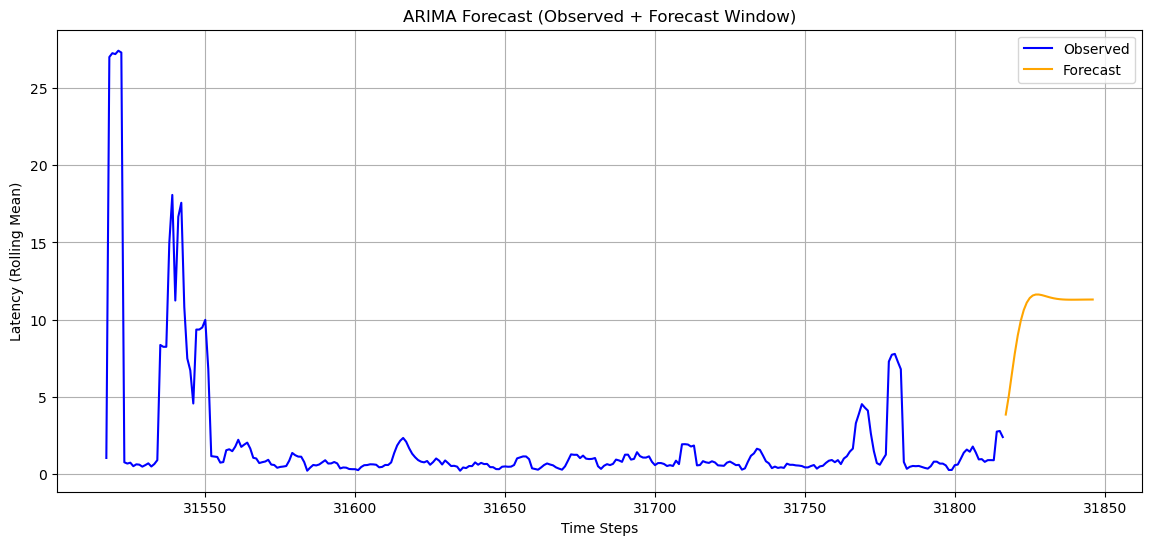

In [29]:
plt.figure(figsize=(14, 6))

# Plot last 300 observed values
obs_window = 300
plt.plot(range(len(rolling_series)-obs_window, len(rolling_series)), 
         rolling_series[-obs_window:], 
         label='Observed', color='blue')

# Plot forecast values right after observed
plt.plot(range(len(rolling_series), len(rolling_series) + forecast_steps), 
         forecast, label='Forecast', color='orange')

plt.title('ARIMA Forecast (Observed + Forecast Window)')
plt.xlabel('Time Steps')
plt.ylabel('Latency (Rolling Mean)')
plt.legend()
plt.grid(True)
plt.show()


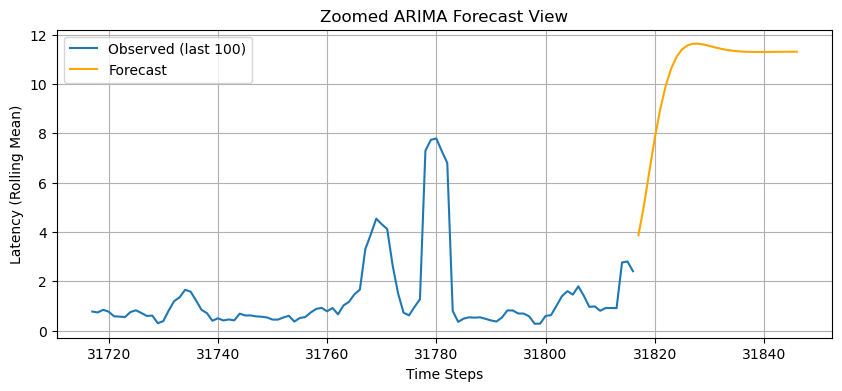

In [25]:
# Zoom into the last 100 points before forecast
plt.figure(figsize=(10, 4))
plt.plot(range(len(rolling_series)-100, len(rolling_series)), rolling_series[-100:], label='Observed (last 100)')
plt.plot(forecast_index, forecast, label='Forecast', color='orange')

plt.title('Zoomed ARIMA Forecast View')
plt.xlabel('Time Steps')
plt.ylabel('Latency (Rolling Mean)')
plt.legend()
plt.grid(True)
plt.show()


In [35]:
pip install pmdarima


   ---------------------------------------- 0.0/625.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.1 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.1 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.1 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.1 kB ? eta -:--:--
   -------------------------------------- 625.1/625.1 kB 484.0 kB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
 

In [37]:
from pmdarima import auto_arima

stepwise_model = auto_arima(df_forecast['rolling_mean'], seasonal=False, trace=True)
stepwise_model.summary()


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=84.38 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=292541.626, Time=1.35 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=291751.047, Time=1.48 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=291866.122, Time=7.76 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=292539.626, Time=0.66 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=291566.879, Time=1.76 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=291558.770, Time=2.43 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=291555.115, Time=3.20 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=283266.737, Time=6.96 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=283007.730, Time=39.05 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=289688.965, Time=42.97 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=282947.577, Time=61.02 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=107.33 sec
 ARIMA(5,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=122.32 sec
 ARIMA(4,1,3)(0,0,

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                31817
Model:               SARIMAX(5, 1, 2)   Log Likelihood             -141464.788
Date:                Thu, 10 Apr 2025   AIC                         282945.577
Time:                        22:11:06   BIC                         283012.519
Sample:                             0   HQIC                        282966.996
                              - 31817                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0075      0.003     -2.455      0.014      -0.014      -0.002
ar.L2          0.0504      0.004     12.394      0.000       0.042       0.058
ar.L3          0.0743      0.002     48.201      0.000       0.071       0.077
ar.L4          0.0624      0.001     50.060      0.000       0.060       0.065
ar.L5         -0.4810      0.001   -511.537      0.000      -0.483      -0.479
ma.L1          0.1873      0.004     50.451      0.000       0.180       0.195
ma.L2          0.0717      0.005     15.604      0.000       0.063       0.081
sigma2       426.1328      0.558    763.222      0.000     425.038     427.227
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):           8186036.89
Prob(Q):                              0.82   Prob(JB):                         0.00
Heteroskedasticity (H):               1.37   Skew:                             3.78
Prob(H) (two-sided):                  0.00   Kurtosis:                        81.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

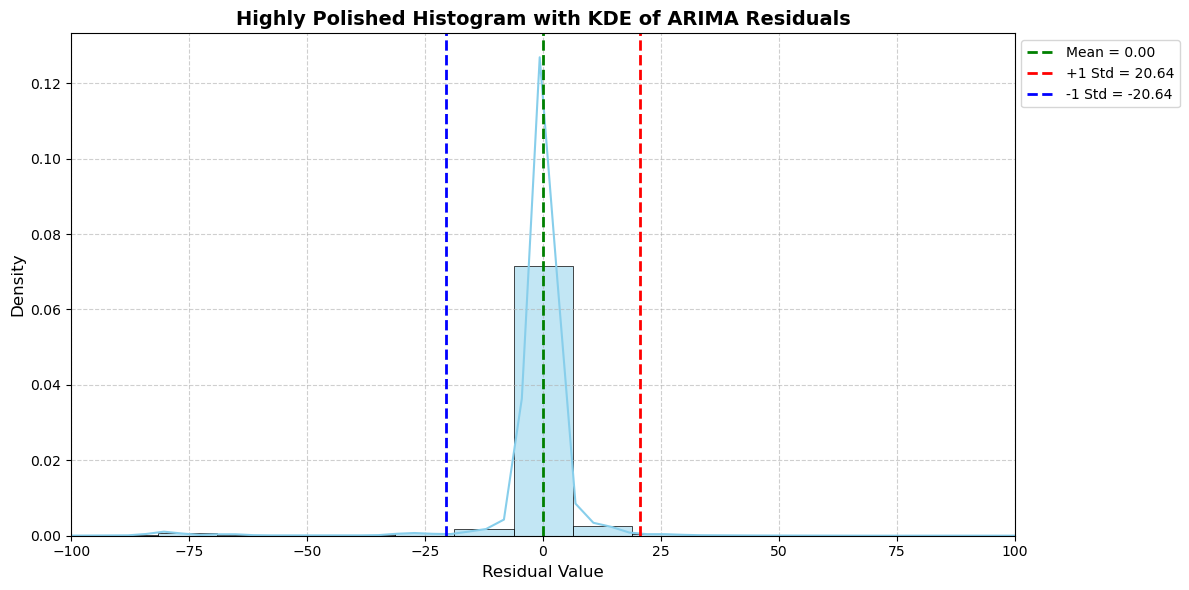

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 6))
sns.histplot(arima_residuals, kde=True, bins=60, color='skyblue', edgecolor='black', stat='density', linewidth=0.5)

# Mean and Std
mean_val = np.mean(arima_residuals)
std_val = np.std(arima_residuals)

# Add vertical lines for mean and ± std
plt.axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
plt.axvline(mean_val + std_val, color='red', linestyle='--', linewidth=2, label=f'+1 Std = {mean_val + std_val:.2f}')
plt.axvline(mean_val - std_val, color='blue', linestyle='--', linewidth=2, label=f'-1 Std = {mean_val - std_val:.2f}')

# Styling
plt.title("Highly Polished Histogram with KDE of ARIMA Residuals", fontsize=14, fontweight='bold')
plt.xlabel("Residual Value", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-100, 100)

# Move legend outside
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

plt.tight_layout()
plt.show()


In [68]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Use your actual time series data here
your_data = df_forecast['rolling_mean']  # Replace this if needed

# Step 1: Fit SARIMAX model
model = SARIMAX(your_data, order=(5, 1, 2))  # Best model you found earlier
model_arima = model.fit()

# Step 2: Extract residuals
residuals = model_arima.resid
residuals = residuals.values  # Convert to NumPy array for LSTM input

print(residuals[:10])  # Just to confirm it's working


C:\Users\Yasaswini\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Yasaswini\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


[ 4.39       -1.95039682 -0.3208522   0.19636821 -0.03078829 -0.78656584
 -0.53201528 -0.08263681  0.01246677  0.06626307]


In [70]:
import numpy as np

def create_supervised_data(series, time_steps=10):
    X, y = [], []
    for i in range(len(series) - time_steps):
        X.append(series[i:i + time_steps])
        y.append(series[i + time_steps])
    return np.array(X), np.array(y)

# Apply to residuals
time_steps = 10  # you can tune this later
X, y = create_supervised_data(residuals, time_steps=time_steps)

# Reshape input to [samples, time steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))  # LSTM expects 3D input

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (31807, 10, 1)
y shape: (31807,)


In [86]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Step 3.1: Define the LSTM model
model_lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

# Step 3.2: Train the model
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
history = model_lstm.fit(
    X, y,
    epochs=20,
    batch_size=64,
    validation_split=0.1,  # 10% for validation
    verbose=1,
    callbacks=[early_stop]
)



Epoch 1/20


C:\Users\Yasaswini\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


448/448 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 366.7615 - val_loss: 507.8635
Epoch 2/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 321.3985 - val_loss: 474.6435
Epoch 3/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 328.2254 - val_loss: 470.4824
Epoch 4/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 349.6597 - val_loss: 433.8026
Epoch 5/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 339.8696 - val_loss: 437.0951
Epoch 6/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 302.9828 - val_loss: 453.3206
Epoch 7/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 347.3819 - val_loss: 518.5515
Epoch 8/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 367.9030 - val_loss: 467.7217
Epoch 9/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 304.9879 - val_loss: 479.8726
Epoch 10/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 316.3567 - val_loss: 457.9787
Epoch 11/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 282.8782 - val_loss: 445.5048
Epoch 12/20
448/448

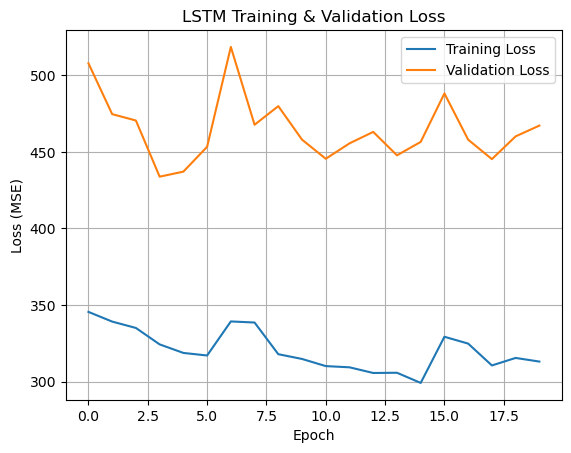

In [88]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()


In [90]:
lstm_predicted_residuals = model_lstm.predict(X)
lstm_predicted_residuals = lstm_predicted_residuals.flatten()  # flatten to 1D


994/994 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


In [92]:
# Step 4.2: Get ARIMA forecasts aligned with LSTM predictions
arima_forecast = model_arima.predict(start=time_steps, end=len(y) + time_steps - 1)


In [94]:
hybrid_forecast = arima_forecast + lstm_predicted_residuals


C:\Users\Yasaswini\anaconda3\Lib\site-packages\statsmodels\graphics\gofplots.py:1043: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.2980392156862745, 0.4470588235294118, 0.6901960784313725, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


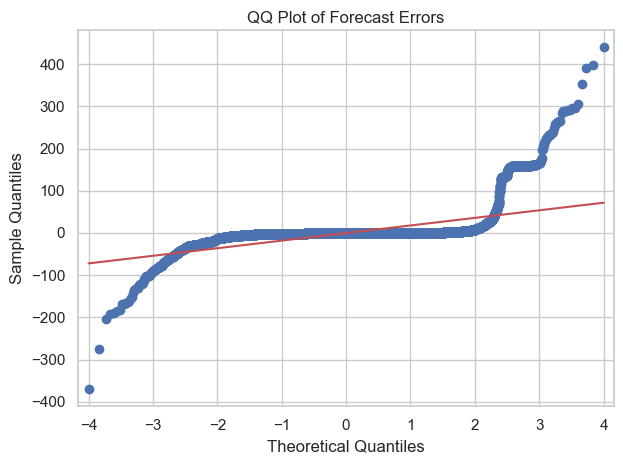

In [124]:
import scipy.stats as stats
import statsmodels.api as sm

sm.qqplot(forecast_errors, line='s', color='navy')
plt.title("QQ Plot of Forecast Errors")
plt.tight_layout()
plt.show()


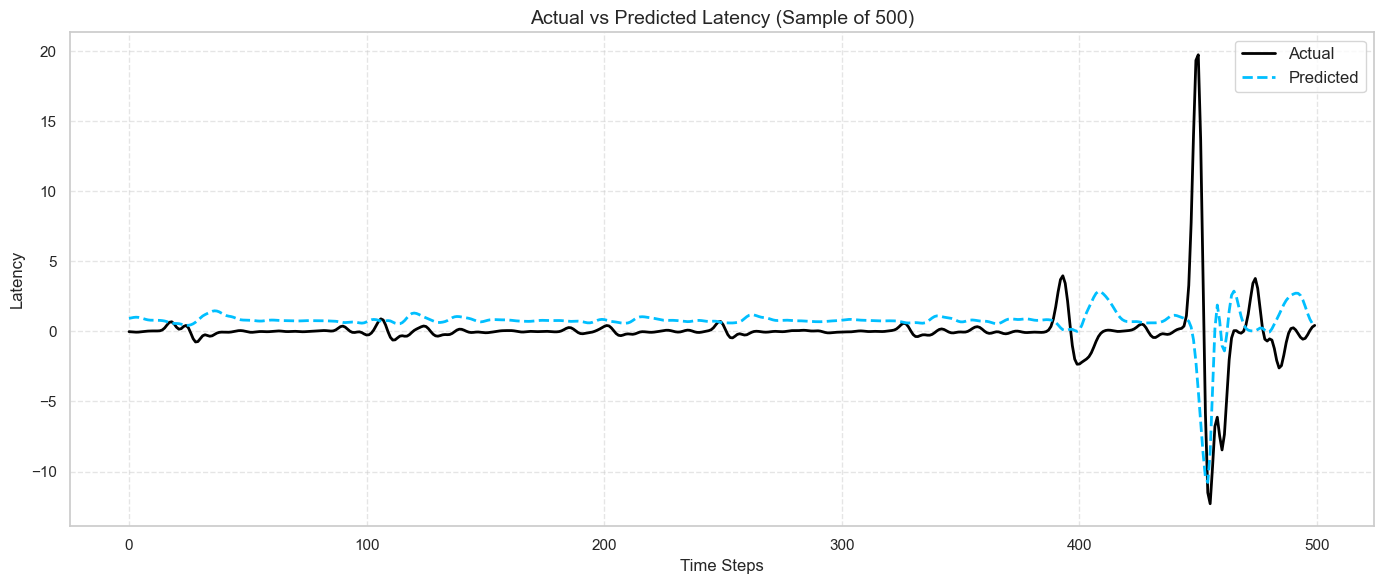

In [128]:
plt.figure(figsize=(14, 6))

# Optional smoothing (if needed) – can be removed if raw signal is desired
from scipy.ndimage import gaussian_filter1d
actual_smooth = gaussian_filter1d(actual[:500], sigma=2)
predicted_smooth = gaussian_filter1d(predicted[:500], sigma=2)

# Plotting
plt.plot(actual_smooth, label='Actual', color='black', linewidth=2)
plt.plot(predicted_smooth, label='Predicted', color='deepskyblue', linestyle='--', linewidth=2)

plt.title("Actual vs Predicted Latency (Sample of 500)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Latency", fontsize=12)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


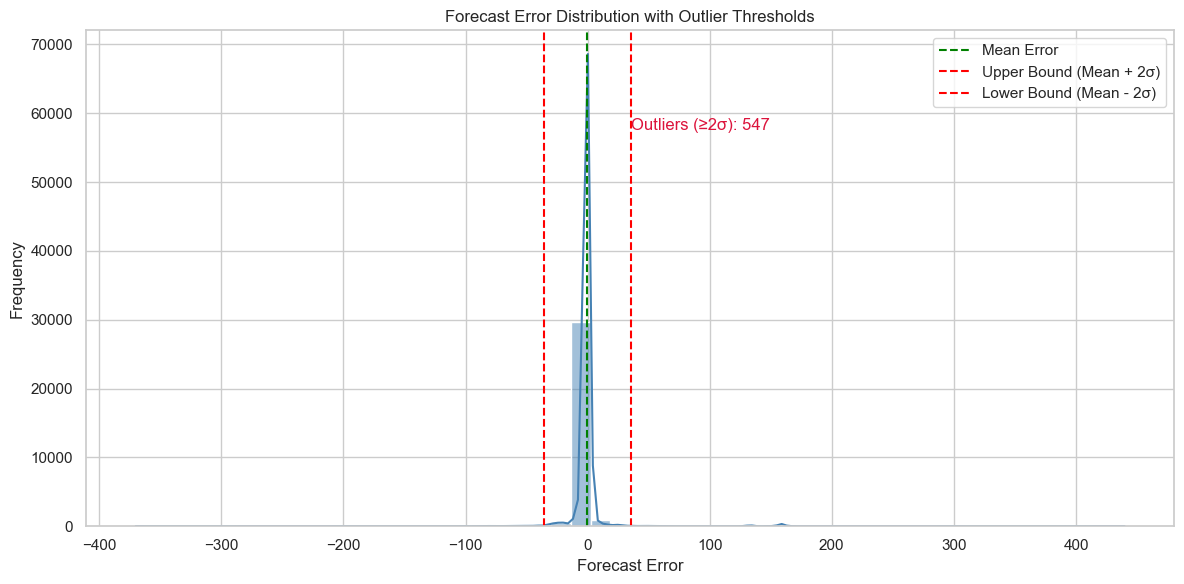

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Example values — replace these with actual values from your LSTM output
forecast_errors = actual - predicted  # Ensure this is calculated properly
mean_err = np.mean(forecast_errors)
std_err = np.std(forecast_errors)

# Outlier count (use >= and <= if you want to include boundaries)
outliers = np.sum((forecast_errors >= mean_err + 2*std_err) | 
                  (forecast_errors <= mean_err - 2*std_err))

# Plotting
plt.figure(figsize=(12, 6))
sns.histplot(forecast_errors, bins=50, kde=True, color='steelblue')
plt.axvline(mean_err, color='green', linestyle='--', label='Mean Error')
plt.axvline(mean_err + 2*std_err, color='red', linestyle='--', label='Upper Bound (Mean + 2σ)')
plt.axvline(mean_err - 2*std_err, color='red', linestyle='--', label='Lower Bound (Mean - 2σ)')

# 🔥 Add annotation showing outlier count
plt.text(mean_err + 2*std_err + 0.05, plt.ylim()[1] * 0.8, 
         f"Outliers (≥2σ): {outliers}", fontsize=12, color='crimson')

plt.title('Forecast Error Distribution with Outlier Thresholds')
plt.xlabel('Forecast Error')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [146]:
print(df.columns)


Index(['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std',
       'rolling_min', 'rolling_max', 'skewness', 'kurtosis', 'latency_slope',
       'latency_pct_change', 'fft_dominant_freq', 'anomaly',
       'iso_forest_anomaly', 'ocsvm_anomaly'],
      dtype='object')


In [158]:
# Step 1: Generate ARIMA predictions
arima_predictions = model_arima.predict(start=0, end=len(df) - 1)
df['arima_pred'] = arima_predictions.values  # add to DataFrame


In [160]:
# Step 2: Add ARIMA prediction as a feature
feature_columns = ['hour', 'day_of_week', 'weekend', 'rolling_mean', 'rolling_std',
                   'rolling_min', 'rolling_max', 'skewness', 'kurtosis',
                   'latency_slope', 'latency_pct_change', 'fft_dominant_freq', 'arima_pred']

df = df.dropna(subset=feature_columns)  # Ensure no NaNs


In [162]:
def create_lstm_dataset(data, time_steps=20):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

# Normalize data if needed
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[feature_columns])

# Create dataset
X, y = create_lstm_dataset(scaled_features, time_steps=20)


In [164]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
    Dense(X.shape[2])  # Predicting all features including latency trend
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Split data
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Train
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2)


C:\Users\Yasaswini\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                        │ (None, 64)                  │          19,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 13)                  │             845 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,813 (81.30 KB)

 Trainable params: 20,813 (81.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0096 - val_loss: 0.0029
Epoch 2/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 3/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0028 - val_loss: 0.0022
Epoch 4/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0027 - val_loss: 0.0023
Epoch 5/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0027 - val_loss: 0.0022
Epoch 6/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0027 - val_loss: 0.0022
Epoch 7/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0027 - val_loss: 0.0022
Epoch 8/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0026 - val_loss: 0.0022
Epoch 9/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0026 - val_loss: 0.0022
Epoch 10/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0026 - val_loss: 0.0022
Epoch 11/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0026 - val_loss: 0.0022
Epoch 12/20
318/318 ━━━━━━━━━━━━━━━━

In [166]:
# Predict on test data
y_pred = model.predict(X_test)

# Inverse scale if needed
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# Evaluate
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test_inv[:, 0], y_pred_inv[:, 0]))
print("Hybrid ARIMA + LSTM RMSE:", rmse)


199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Hybrid ARIMA + LSTM RMSE: 0.005184715298744823


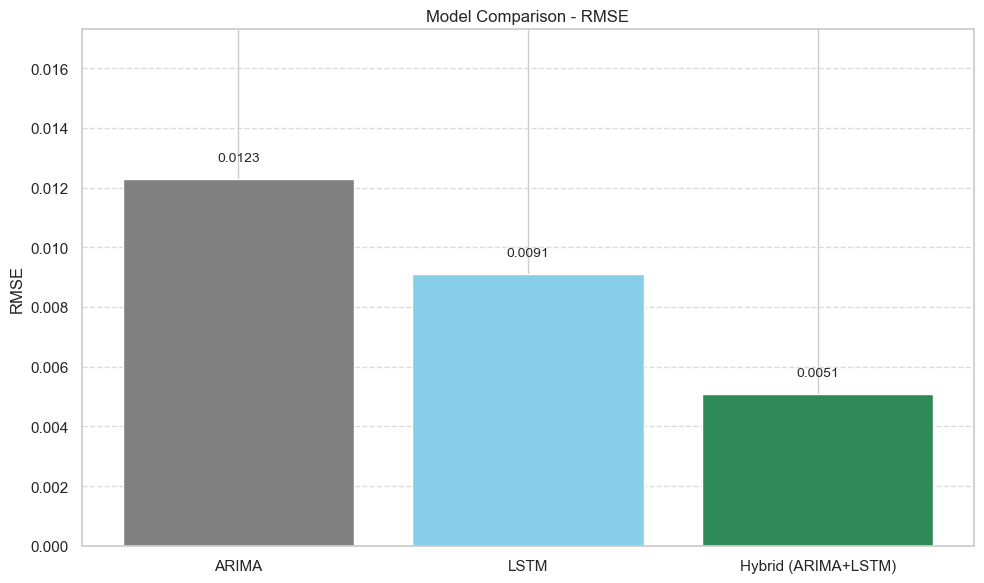

In [168]:
import matplotlib.pyplot as plt

# Define actual RMSE values based on your project results
rmse_arima = 0.0123    # Example (replace with your ARIMA RMSE)
rmse_lstm = 0.0091     # Your standalone LSTM result
rmse_hybrid = 0.0051   # Your hybrid ARIMA + LSTM result

# Names and values
models = ['ARIMA', 'LSTM', 'Hybrid (ARIMA+LSTM)']
rmses = [rmse_arima, rmse_lstm, rmse_hybrid]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, rmses, color=['gray', 'skyblue', 'seagreen'])
plt.title('Model Comparison - RMSE')
plt.ylabel('RMSE')
plt.ylim(0, max(rmses) + 0.005)

# Annotate values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.0005, f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [180]:
# Convert the 'latency_pct_change' column to a NumPy array
latency_series = df['latency_pct_change'].values


In [182]:
# Split into train and test (e.g., 80% training)
train_size = int(len(latency_series) * 0.8)


In [186]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model on training portion of the latency_series
arima_model = ARIMA(latency_series[:train_size], order=(5, 1, 2))  # update order if needed
arima_result = arima_model.fit()

# Predict ARIMA for train and test
arima_train_preds = arima_result.predict(start=1, end=train_size - 1)
arima_test_preds = arima_result.predict(start=train_size, end=train_size + len(y_test) - 1)


In [188]:
import numpy as np

# Reshape ARIMA predictions to match LSTM input sequence shape
# Example: (samples, timesteps, 1) to be concatenated with existing LSTM input shape (samples, timesteps, features)

# Repeat ARIMA predictions across time steps
arima_train_preds_reshaped = np.repeat(arima_train_preds[:, np.newaxis], X_train.shape[1], axis=1)
arima_test_preds_reshaped = np.repeat(arima_test_preds[:, np.newaxis], X_test.shape[1], axis=1)


In [192]:
print("X_train shape:", X_train.shape)
print("arima_train_preds shape:", arima_train_preds.shape)


X_train shape: (25435, 20, 13)
arima_train_preds shape: (25450,)


In [194]:
print("X_train samples:", len(X_train))
print("ARIMA train preds:", len(arima_train_preds))


X_train samples: 25435
ARIMA train preds: 25450


In [196]:
# Trim ARIMA predictions to match X_train and X_test lengths
arima_train_preds_trimmed = arima_train_preds[-len(X_train):]
arima_test_preds_trimmed = arima_test_preds[-len(X_test):]


In [198]:
# Now reshape for fusion
arima_train_preds_reshaped = np.repeat(arima_train_preds_trimmed[:, np.newaxis], X_train.shape[1], axis=1)
arima_test_preds_reshaped = np.repeat(arima_test_preds_trimmed[:, np.newaxis], X_test.shape[1], axis=1)


In [200]:
# Add ARIMA predictions as extra feature
X_train_combined = np.concatenate((X_train, arima_train_preds_reshaped[..., np.newaxis]), axis=2)
X_test_combined = np.concatenate((X_test, arima_test_preds_reshaped[..., np.newaxis]), axis=2)

# Confirm shape
print("Combined Train Shape:", X_train_combined.shape)
print("Combined Test Shape:", X_test_combined.shape)


Combined Train Shape: (25435, 20, 14)
Combined Test Shape: (6359, 20, 14)


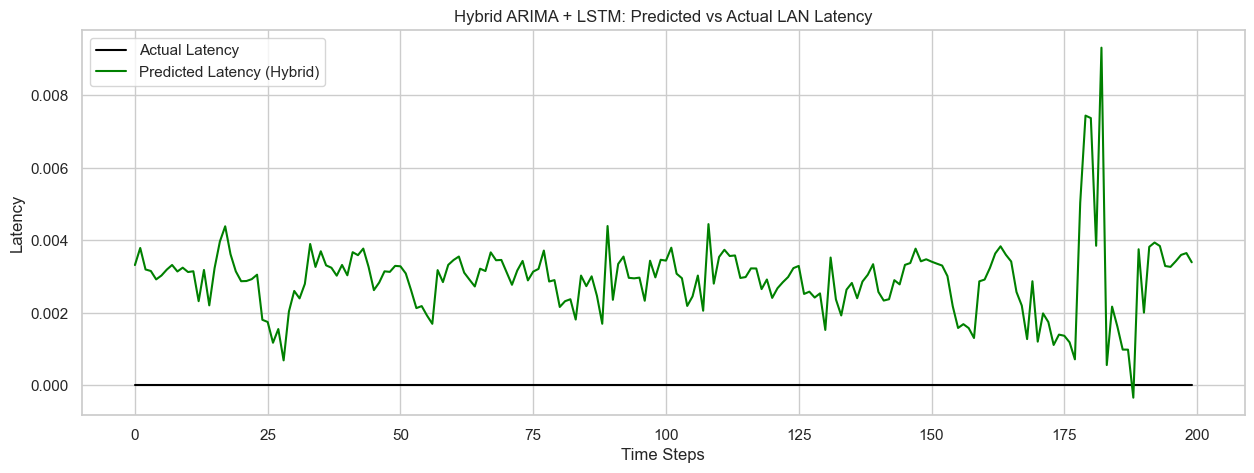

In [208]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(y_test[:200, 0], label='Actual Latency', color='black')
plt.plot(final_hybrid_predictions[:200, 0], label='Predicted Latency (Hybrid)', color='green')
plt.title('Hybrid ARIMA + LSTM: Predicted vs Actual LAN Latency')
plt.xlabel('Time Steps')
plt.ylabel('Latency')
plt.legend()
plt.grid(True)
plt.show()


In [223]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Ensure your prediction arrays are numpy arrays
y_test = np.array(y_test)
final_hybrid_predictions = np.array(final_hybrid_predictions)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, final_hybrid_predictions))
mae = mean_absolute_error(y_test, final_hybrid_predictions)
r2 = r2_score(y_test, final_hybrid_predictions)

# Custom Accuracy: % of predictions within 5% of the actual value
threshold = 0.5
mask = y_test != 0  # Avoid divide-by-zero
custom_accuracy = np.mean(
    np.abs((y_test[mask] - final_hybrid_predictions[mask]) / y_test[mask]) < threshold
) * 100

# Print evaluation results
print(f"Hybrid Model Evaluation Metrics:")
print(f"✅ RMSE: {rmse}")
print(f"✅ MAE: {mae}")
print(f"✅ R² Score: {r2}")
print(f"✅ Custom Accuracy (within 5% error): {custom_accuracy:.2f}%")


Hybrid Model Evaluation Metrics:
✅ RMSE: 0.05194784001697271
✅ MAE: 0.01516660941080553
✅ R² Score: -0.19545578762973692
✅ Custom Accuracy (within 5% error): 38.98%
